# Prediccion de Fuga de Clientes (Churn) — Sector Automocion

**Objetivo:** Predecir la probabilidad de abandono de cada cliente de un concesionario oficial
y disenar una estrategia comercial rentable basada en las predicciones.

**Definicion de Churn:** Cliente con mas de 400 dias sin revision tecnica en el taller oficial.

**Datasets:**
- \ — 58.049 registros historicos (sandbox)
- \ — 10.000 clientes nuevos (staging)
- \ — Parametros economicos por modelo

---

| Seccion | Contenido |
|:-------:|-----------|
| 1 | Configuracion |
| 2 | Carga de datos |
| 3 | Calidad y limpieza |
| 4 | Analisis exploratorio (EDA) |
| 5 | Analisis de Churn |
| 6 | Feature Engineering |
| 7 | Modelado |
| 8 | Feature Importance, SHAP y Evaluacion |
| 9 | Staging (produccion) |
| 10 | Estrategia comercial |
| 11 | Conclusiones y recomendaciones |
| 12 | Exportar artefactos (Streamlit) |


---
## 1. Configuracion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Estilo global ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.bbox': 'tight',
})

# Paleta de colores
C_NO   = '#27ae60'   # No Churn (verde)
C_SI   = '#e74c3c'   # Churn (rojo)
C_BLUE = '#3498db'   # Neutro (azul)
C_WARN = '#f39c12'   # Warning (naranja)
C_PURP = '#9b59b6'   # Acento (morado)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Entorno configurado.')

Entorno configurado.


---
## 2. Carga de datos

In [2]:
# --- Fuentes de datos ---
df = pd.read_csv('bqresults.csv')
costes = pd.read_csv('Costes.csv')
nuevos = pd.read_csv('nuevos_clientes.csv')

# Enriquecimiento: merge con tabla de costes
df = df.merge(costes, on='Modelo', how='left')

print('DATOS CARGADOS')
print('=' * 50)
print(f'  Historico (sandbox):  {df.shape[0]:>6,} filas x {df.shape[1]} cols')
print(f'  Costes por modelo:    {costes.shape[0]:>6} filas x {costes.shape[1]} cols')
print(f'  Nuevos (staging):     {nuevos.shape[0]:>6,} filas x {nuevos.shape[1]} cols')
print(f'  Clientes unicos:      {df["Customer_ID"].nunique():>6,}')
print(f'  Modelos:              {df["Modelo"].nunique():>6}')

DATOS CARGADOS
  Historico (sandbox):  58,049 filas x 46 cols
  Costes por modelo:        11 filas x 7 cols
  Nuevos (staging):     10,000 filas x 38 cols
  Clientes unicos:      44,053
  Modelos:                  11


---
## 3. Calidad y limpieza

Se aplica un pipeline de limpieza reproducible:
- Nulos semanticos: `QUEJA`, `STATUS_SOCIAL`, `GENERO`
- Typo corregido en `EXTENSION_GARANTIA`
- **Leakage eliminado:** `DAYS_LAST_SERVICE` (correlacion directa con el target)
- Fechas parseadas y variables temporales derivadas

In [3]:
# --- Analisis de nulos ---
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

print('VARIABLES CON NULOS')
print('-' * 50)
for var, n in nulos.items():
    print(f'  {var:35s} {n:>6,} ({n/len(df)*100:.1f}%)')

# --- Pipeline de limpieza ---
def limpiar_datos(df):
    """Pipeline de limpieza reproducible (Sandbox y Staging)."""
    df = df.copy()
    df['QUEJA'] = df['QUEJA'].fillna('SIN_REGISTRO')
    df['STATUS_SOCIAL'] = df['STATUS_SOCIAL'].fillna('DESCONOCIDO')
    df['GENERO'] = df['GENERO'].fillna('DESCONOCIDO')
    df['EXTENSION_GARANTIA'] = df['EXTENSION_GARANTIA'].replace(
        'SI, Campa a Regalo', 'SI, Campana Regalo')
    if 'DAYS_LAST_SERVICE' in df.columns:
        df = df.drop(columns=['DAYS_LAST_SERVICE'])
    if 'Churn_400' in df.columns:
        df['Churn'] = (df['Churn_400'] == 'Y').astype(int)
    df['Sales_Date'] = pd.to_datetime(df['Sales_Date'], format='%d/%m/%Y')
    df['FIN_GARANTIA'] = pd.to_datetime(df['FIN_GARANTIA'], format='%d/%m/%Y')
    df['BASE_DATE'] = pd.to_datetime(df['BASE_DATE'], format='%d/%m/%Y')
    return df

df = limpiar_datos(df)

# Variables temporales
df['Antiguedad_dias'] = (df['BASE_DATE'] - df['Sales_Date']).dt.days
df['Dias_fin_garantia'] = (df['FIN_GARANTIA'] - df['BASE_DATE']).dt.days

print(f'\nLIMPIEZA APLICADA')
print('=' * 50)
print(f'  Shape final:          {df.shape[0]:,} x {df.shape[1]}')
print(f'  Nulos restantes:      {df.isnull().sum().sum()}')
print(f'  Leakage eliminado:    DAYS_LAST_SERVICE')
print(f'  Antiguedad media:     {df["Antiguedad_dias"].mean():.0f} dias ({df["Antiguedad_dias"].mean()/365.25:.1f} anos)')

VARIABLES CON NULOS
--------------------------------------------------
  QUEJA                               33,323 (57.4%)
  DAYS_LAST_SERVICE                   27,070 (46.6%)
  STATUS_SOCIAL                       12,816 (22.1%)
  GENERO                                 849 (1.5%)

LIMPIEZA APLICADA
  Shape final:          58,049 x 48
  Nulos restantes:      0
  Leakage eliminado:    DAYS_LAST_SERVICE
  Antiguedad media:     945 dias (2.6 anos)


---
## 4. Analisis Exploratorio (EDA)

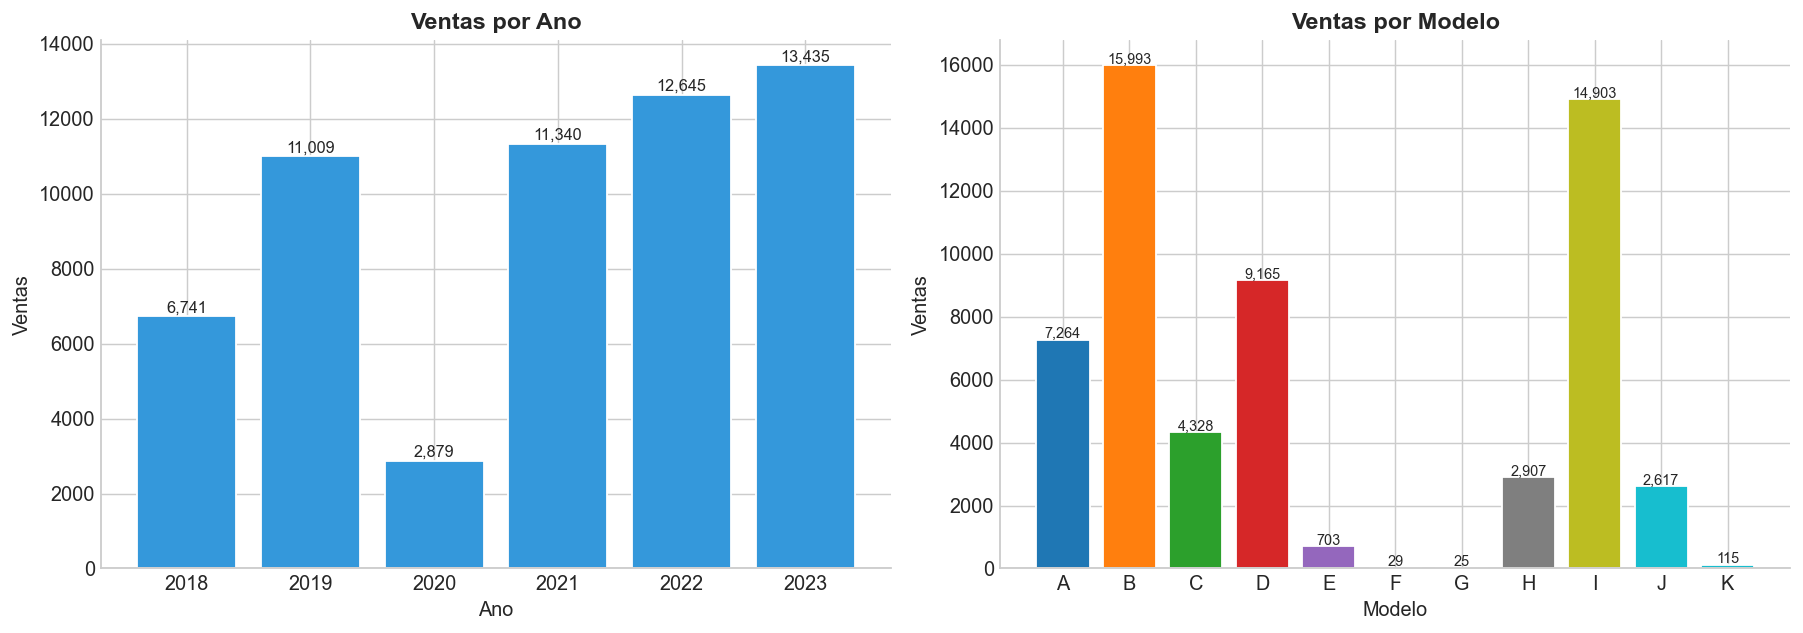

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ventas por ano
ventas_ano = df['Sales_Date'].dt.year.value_counts().sort_index()
bars = axes[0].bar(ventas_ano.index, ventas_ano.values, color=C_BLUE, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 100, f'{h:,.0f}',
                 ha='center', fontsize=9)
axes[0].set_title('Ventas por Ano')
axes[0].set_xlabel('Ano'); axes[0].set_ylabel('Ventas')

# Ventas por modelo
ventas_mod = df['Modelo'].value_counts().sort_index()
axes[1].bar(ventas_mod.index, ventas_mod.values, color=plt.cm.tab10(range(len(ventas_mod))),
            edgecolor='white')
for i, (m, v) in enumerate(ventas_mod.items()):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=8)
axes[1].set_title('Ventas por Modelo')
axes[1].set_xlabel('Modelo'); axes[1].set_ylabel('Ventas')

plt.tight_layout()
plt.show()

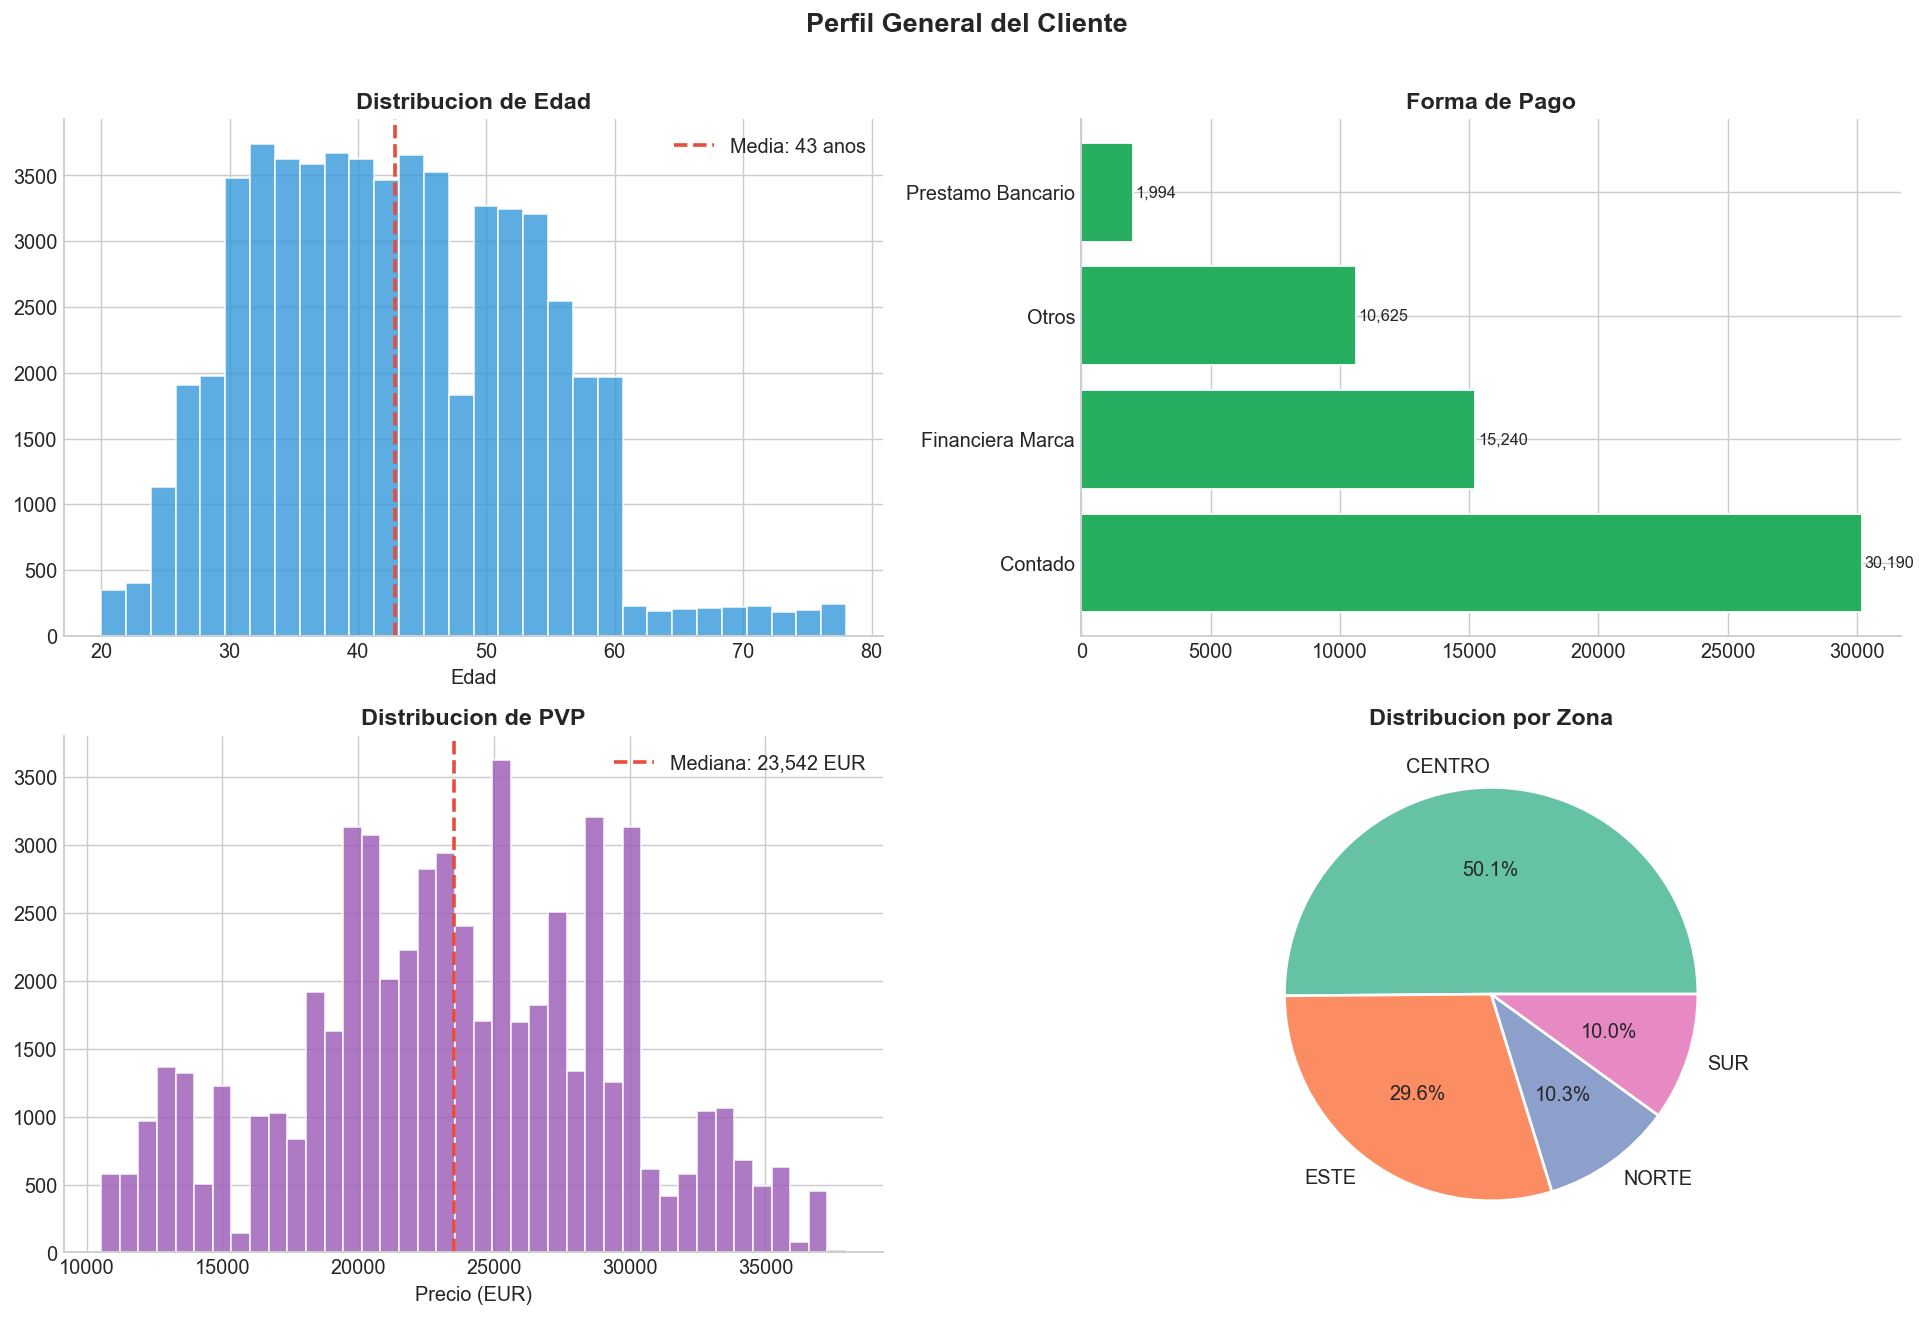

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Edad
axes[0,0].hist(df['Edad'], bins=30, color=C_BLUE, edgecolor='white', alpha=0.8)
axes[0,0].axvline(df['Edad'].mean(), color=C_SI, ls='--', lw=2,
                   label=f'Media: {df["Edad"].mean():.0f} anos')
axes[0,0].set_title('Distribucion de Edad')
axes[0,0].set_xlabel('Edad'); axes[0,0].legend()

# Forma de pago
fp = df['FORMA_PAGO'].value_counts()
axes[0,1].barh(fp.index, fp.values, color=C_NO, edgecolor='white')
for i, v in enumerate(fp.values):
    axes[0,1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)
axes[0,1].set_title('Forma de Pago')

# PVP
axes[1,0].hist(df['PVP'], bins=40, color=C_PURP, edgecolor='white', alpha=0.8)
axes[1,0].axvline(df['PVP'].median(), color=C_SI, ls='--', lw=2,
                   label=f'Mediana: {df["PVP"].median():,.0f} EUR')
axes[1,0].set_title('Distribucion de PVP')
axes[1,0].set_xlabel('Precio (EUR)'); axes[1,0].legend()

# Zona
zona = df['ZONA'].value_counts()
axes[1,1].pie(zona.values, labels=zona.index, autopct='%1.1f%%',
              colors=plt.cm.Set2.colors[:len(zona)],
              wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1,1].set_title('Distribucion por Zona')

plt.suptitle('Perfil General del Cliente', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

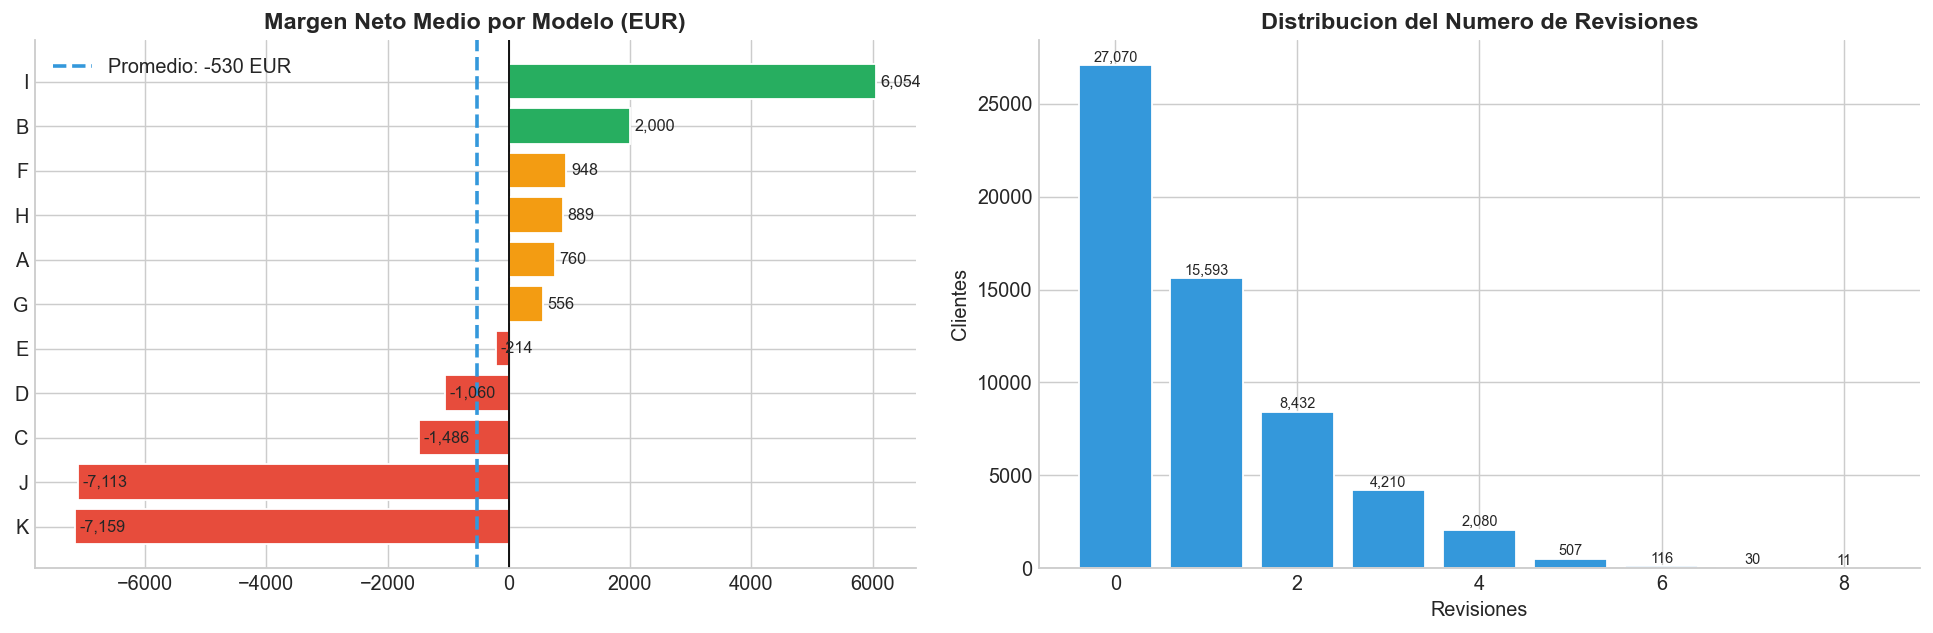

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Margen neto medio por modelo
margen_mod = df.groupby('Modelo')['Margen_eur'].mean().sort_values(ascending=True)
colores = [C_SI if v < 0 else C_NO if v > 1000 else C_WARN for v in margen_mod.values]
axes[0].barh(margen_mod.index, margen_mod.values, color=colores, edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].axvline(margen_mod.mean(), color=C_BLUE, ls='--', lw=2,
                label=f'Promedio: {margen_mod.mean():,.0f} EUR')
for modelo, val in margen_mod.items():
    axes[0].text(val + 80, modelo, f'{val:,.0f}', va='center', fontsize=9)
axes[0].set_title('Margen Neto Medio por Modelo (EUR)')
axes[0].legend()

# Revisiones
rev = df['Revisiones'].value_counts().sort_index()
axes[1].bar(rev.index, rev.values, color=C_BLUE, edgecolor='white')
for n, v in rev.items():
    axes[1].text(n, v + 200, f'{v:,}', ha='center', fontsize=8)
axes[1].set_title('Distribucion del Numero de Revisiones')
axes[1].set_xlabel('Revisiones'); axes[1].set_ylabel('Clientes')

plt.tight_layout()
plt.show()

---
## 5. Analisis de Churn (Variable Objetivo)

DISTRIBUCION DE CHURN
  No Churn (N): 52,956  (91.2%)
  Churn    (Y):  5,093  (8.8%)
  Ratio:        10:1


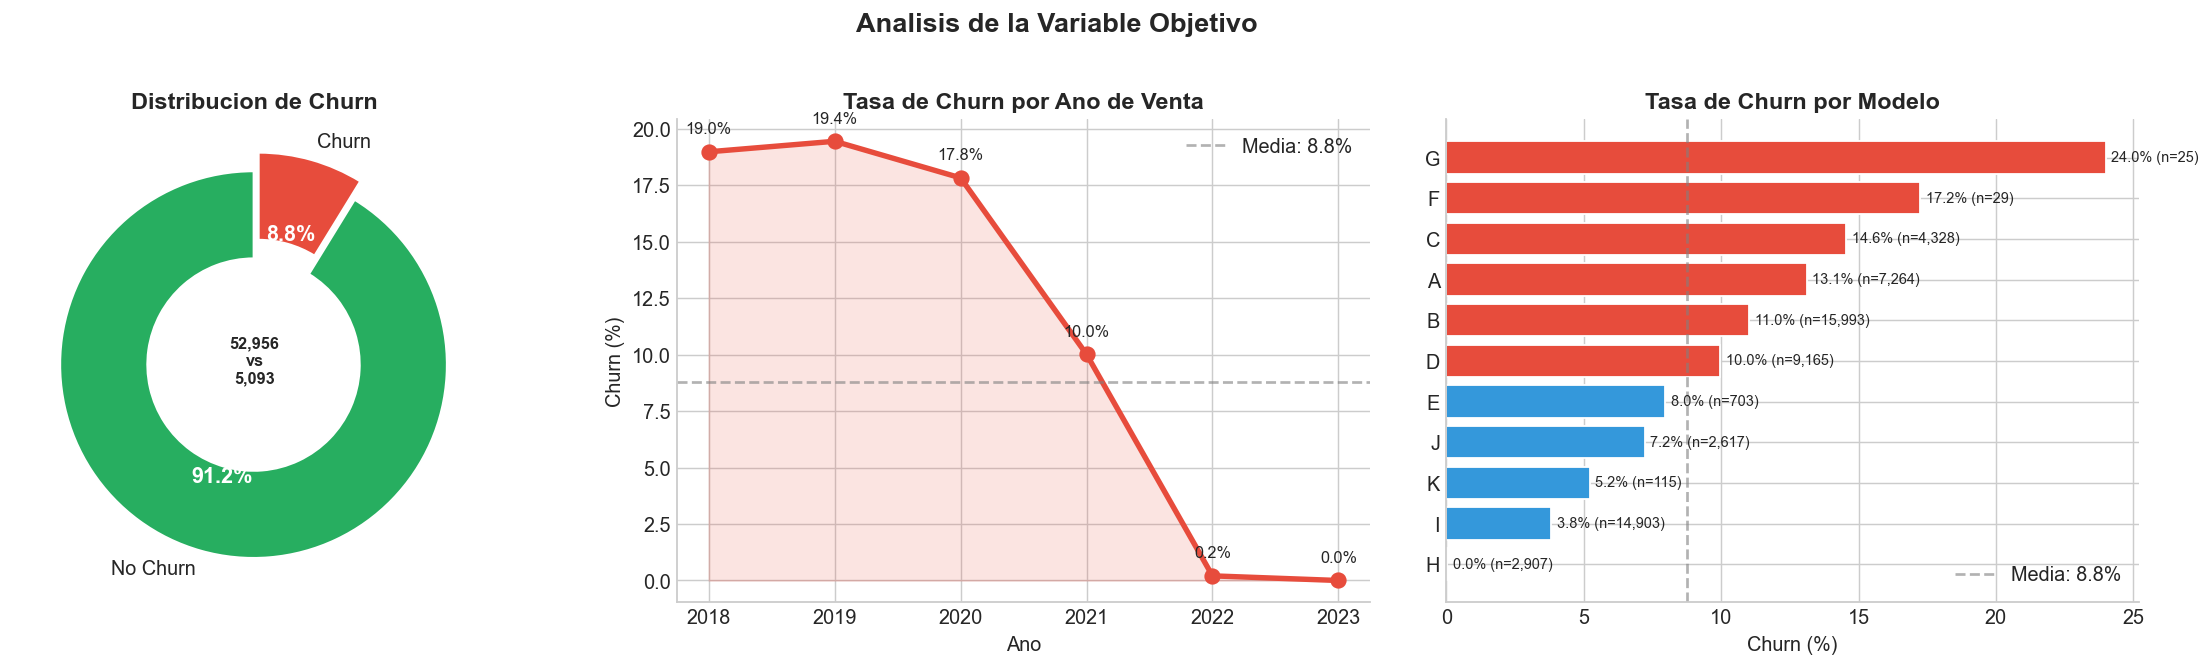

In [7]:
churn_n = df['Churn_400'].value_counts()
churn_pct = df['Churn_400'].value_counts(normalize=True) * 100

print('DISTRIBUCION DE CHURN')
print('=' * 45)
print(f'  No Churn (N): {churn_n["N"]:>6,}  ({churn_pct["N"]:.1f}%)')
print(f'  Churn    (Y): {churn_n["Y"]:>6,}  ({churn_pct["Y"]:.1f}%)')
print(f'  Ratio:        {churn_n["N"]/churn_n["Y"]:.0f}:1')

# --- Visualizacion ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Donut
sizes = [churn_n['N'], churn_n['Y']]
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=['No Churn', 'Churn'], colors=[C_NO, C_SI],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white'),
    explode=(0.02, 0.08), textprops={'fontsize': 11})
for t in autotexts:
    t.set_fontweight('bold'); t.set_color('white'); t.set_fontsize(12)
axes[0].text(0, 0, f'{churn_n["N"]:,}\nvs\n{churn_n["Y"]:,}',
             ha='center', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribucion de Churn')

# 2. Tendencia temporal
churn_ano = df.groupby(df['Sales_Date'].dt.year)['Churn'].agg(['sum','count'])
churn_ano['pct'] = churn_ano['sum'] / churn_ano['count'] * 100
axes[1].plot(churn_ano.index, churn_ano['pct'], marker='o', color=C_SI, lw=3, markersize=8)
axes[1].fill_between(churn_ano.index, churn_ano['pct'], alpha=0.15, color=C_SI)
axes[1].axhline(y=df['Churn'].mean()*100, color='grey', ls='--', alpha=0.6,
                label=f'Media: {df["Churn"].mean()*100:.1f}%')
for y, pct in churn_ano['pct'].items():
    axes[1].annotate(f'{pct:.1f}%', (y, pct), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)
axes[1].set_title('Tasa de Churn por Ano de Venta')
axes[1].set_xlabel('Ano'); axes[1].set_ylabel('Churn (%)')
axes[1].legend()

# 3. Churn por modelo
churn_mod = df.groupby('Modelo')['Churn'].mean().sort_values(ascending=True) * 100
media_global = df['Churn'].mean() * 100
colores = [C_SI if v > media_global else C_BLUE for v in churn_mod.values]
axes[2].barh(churn_mod.index, churn_mod.values, color=colores, edgecolor='white')
axes[2].axvline(media_global, color='grey', ls='--', alpha=0.6,
                label=f'Media: {media_global:.1f}%')
for i, (m, v) in enumerate(churn_mod.items()):
    n = (df['Modelo'] == m).sum()
    axes[2].text(v + 0.2, i, f'{v:.1f}% (n={n:,})', va='center', fontsize=8)
axes[2].set_title('Tasa de Churn por Modelo')
axes[2].set_xlabel('Churn (%)'); axes[2].legend()

plt.suptitle('Analisis de la Variable Objetivo', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

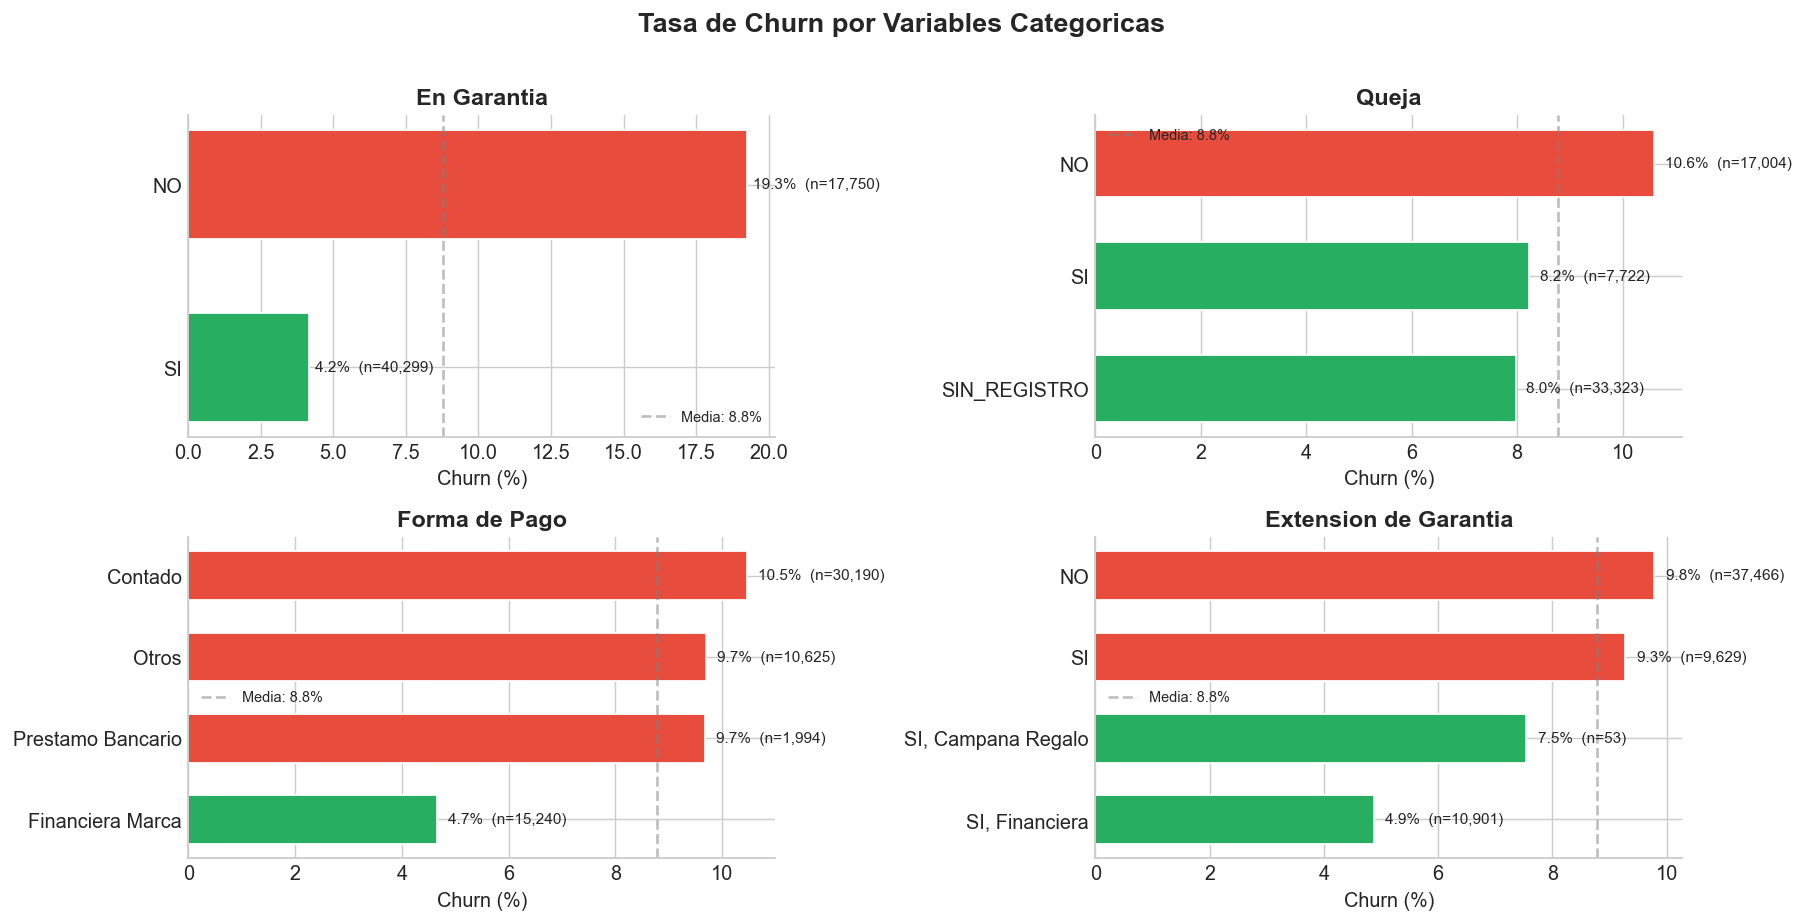

In [8]:
# Churn rate por variables categoricas discriminantes
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

cat_vars = [
    ('EN_GARANTIA', 'En Garantia'),
    ('QUEJA', 'Queja'),
    ('FORMA_PAGO', 'Forma de Pago'),
    ('EXTENSION_GARANTIA', 'Extension de Garantia'),
]

for ax, (var, title) in zip(axes.flatten(), cat_vars):
    churn_rate = df.groupby(var)['Churn'].agg(['mean', 'count'])
    churn_rate['pct'] = churn_rate['mean'] * 100
    churn_rate = churn_rate.sort_values('pct', ascending=True)
    
    colores = [C_SI if v > media_global else C_NO for v in churn_rate['pct']]
    bars = ax.barh(churn_rate.index, churn_rate['pct'], color=colores,
                   edgecolor='white', height=0.6)
    ax.axvline(media_global, color='grey', ls='--', alpha=0.5,
               label=f'Media: {media_global:.1f}%')
    
    for i, (cat, row) in enumerate(churn_rate.iterrows()):
        ax.text(row['pct'] + 0.2, i,
                f'{row["pct"]:.1f}%  (n={row["count"]:,.0f})',
                va='center', fontsize=8.5)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Churn (%)')
    ax.legend(fontsize=8)

plt.suptitle('Tasa de Churn por Variables Categoricas',
             fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

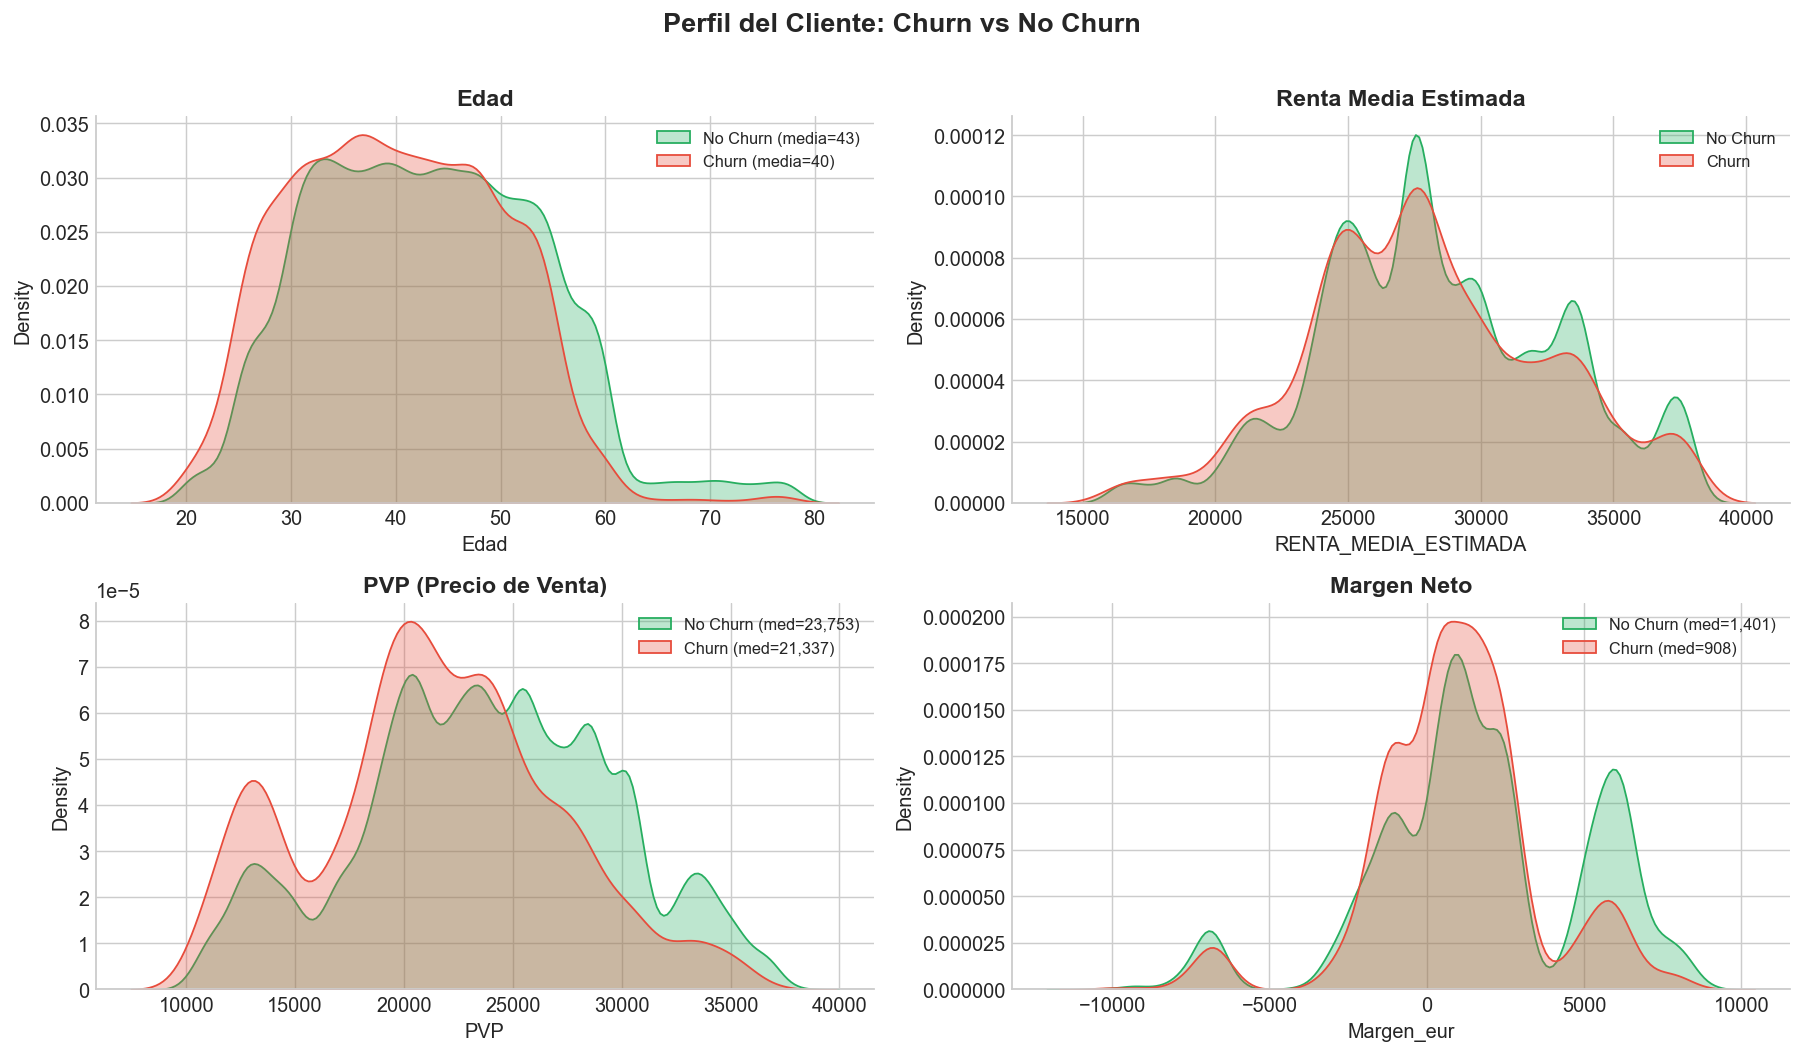

In [9]:
# KDE: perfil numerico Churn vs No Churn
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df_ch = df[df['Churn'] == 1]
df_nc = df[df['Churn'] == 0]

# Edad
sns.kdeplot(df_nc['Edad'], ax=axes[0,0], color=C_NO, fill=True, alpha=0.3,
            label=f'No Churn (media={df_nc["Edad"].mean():.0f})')
sns.kdeplot(df_ch['Edad'], ax=axes[0,0], color=C_SI, fill=True, alpha=0.3,
            label=f'Churn (media={df_ch["Edad"].mean():.0f})')
axes[0,0].set_title('Edad'); axes[0,0].legend(fontsize=9)

# Renta
df_nc_r = df_nc[df_nc['RENTA_MEDIA_ESTIMADA'] > 0]
df_ch_r = df_ch[df_ch['RENTA_MEDIA_ESTIMADA'] > 0]
sns.kdeplot(df_nc_r['RENTA_MEDIA_ESTIMADA'], ax=axes[0,1], color=C_NO,
            fill=True, alpha=0.3, label='No Churn')
sns.kdeplot(df_ch_r['RENTA_MEDIA_ESTIMADA'], ax=axes[0,1], color=C_SI,
            fill=True, alpha=0.3, label='Churn')
axes[0,1].set_title('Renta Media Estimada'); axes[0,1].legend(fontsize=9)

# PVP
sns.kdeplot(df_nc['PVP'], ax=axes[1,0], color=C_NO, fill=True, alpha=0.3,
            label=f'No Churn (med={df_nc["PVP"].median():,.0f})')
sns.kdeplot(df_ch['PVP'], ax=axes[1,0], color=C_SI, fill=True, alpha=0.3,
            label=f'Churn (med={df_ch["PVP"].median():,.0f})')
axes[1,0].set_title('PVP (Precio de Venta)'); axes[1,0].legend(fontsize=9)

# Margen
sns.kdeplot(df_nc['Margen_eur'], ax=axes[1,1], color=C_NO, fill=True, alpha=0.3,
            label=f'No Churn (med={df_nc["Margen_eur"].median():,.0f})')
sns.kdeplot(df_ch['Margen_eur'], ax=axes[1,1], color=C_SI, fill=True, alpha=0.3,
            label=f'Churn (med={df_ch["Margen_eur"].median():,.0f})')
axes[1,1].set_title('Margen Neto'); axes[1,1].legend(fontsize=9)

plt.suptitle('Perfil del Cliente: Churn vs No Churn',
             fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

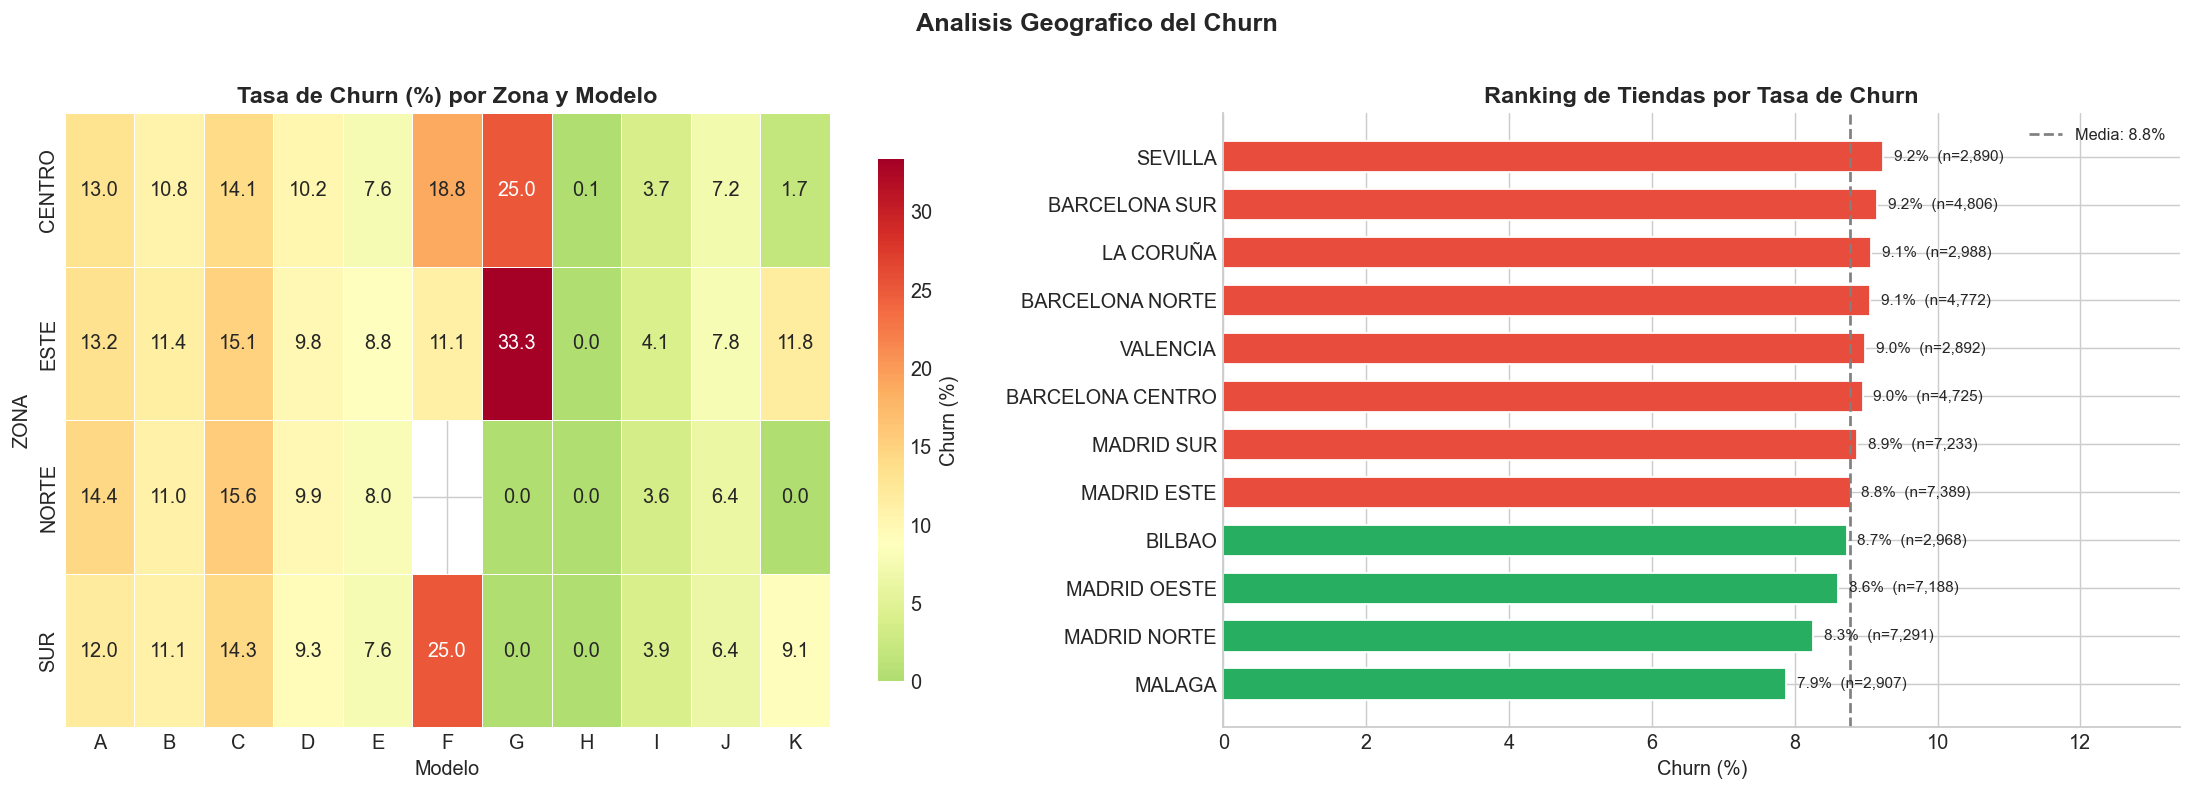

In [10]:
# --- Analisis geografico ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Heatmap Zona x Modelo
pivot = df.pivot_table(values='Churn', index='ZONA', columns='Modelo', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=media_global, ax=axes[0],
            cbar_kws={'label': 'Churn (%)', 'shrink': 0.85},
            linewidths=0.5, linecolor='white', vmin=0)
axes[0].set_title('Tasa de Churn (%) por Zona y Modelo')

# Ranking de tiendas
churn_tienda = (df.groupby('TIENDA_DESC')['Churn']
                .agg(['mean', 'count']).reset_index())
churn_tienda.columns = ['Tienda', 'Churn_rate', 'N']
churn_tienda['Churn_rate'] *= 100
churn_tienda = churn_tienda.sort_values('Churn_rate', ascending=True)

colors_t = [C_SI if v > media_global else C_NO for v in churn_tienda['Churn_rate']]
axes[1].barh(churn_tienda['Tienda'], churn_tienda['Churn_rate'],
             color=colors_t, edgecolor='white', height=0.65)
axes[1].axvline(media_global, color='grey', ls='--', lw=1.5,
                label=f'Media: {media_global:.1f}%')
for _, row in churn_tienda.iterrows():
    axes[1].text(row['Churn_rate'] + 0.15, row['Tienda'],
                 f'{row["Churn_rate"]:.1f}%  (n={row["N"]:,})',
                 va='center', fontsize=8.5)
axes[1].set_title('Ranking de Tiendas por Tasa de Churn')
axes[1].set_xlabel('Churn (%)'); axes[1].legend(fontsize=9)
axes[1].set_xlim(0, churn_tienda['Churn_rate'].max() * 1.45)

plt.suptitle('Analisis Geografico del Churn',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

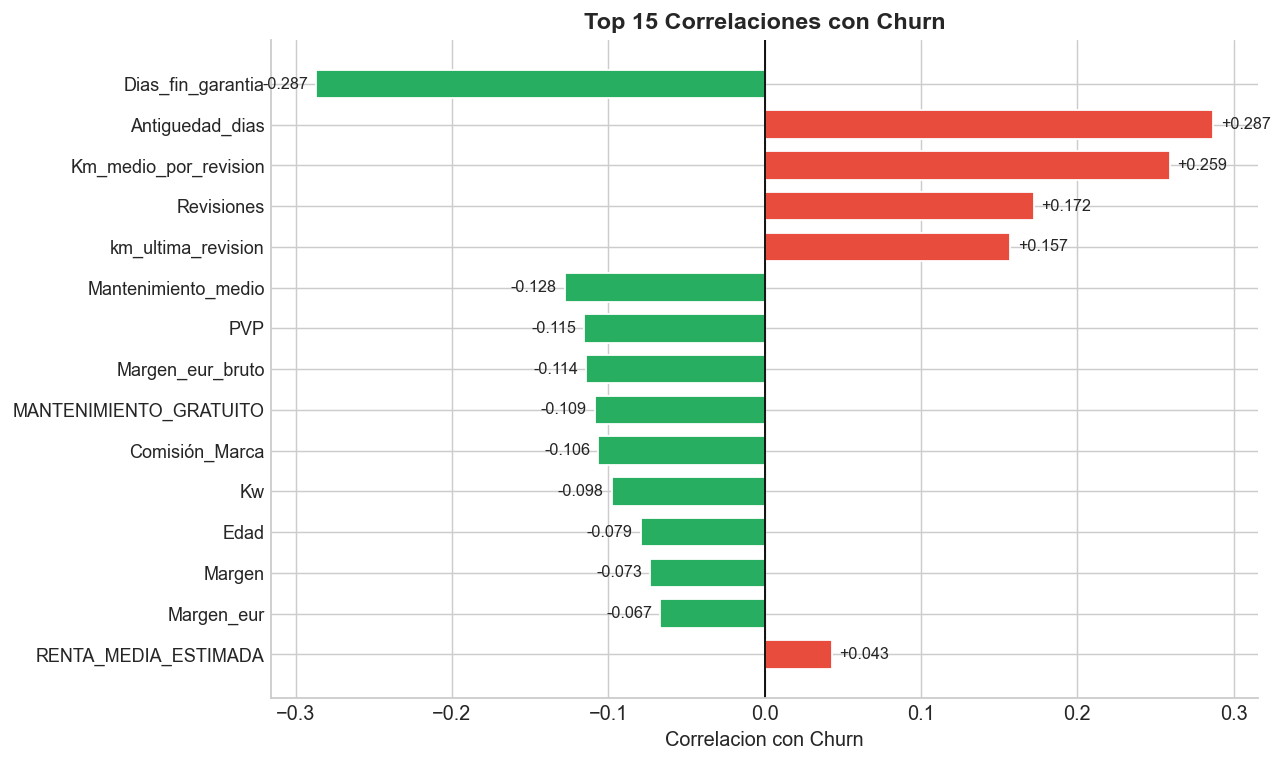

In [11]:
# --- Correlaciones con Churn ---
vars_num = df.select_dtypes(include='number').columns.tolist()
corr_churn = (df[vars_num].corr()['Churn']
              .drop('Churn').sort_values(key=abs, ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [C_SI if v > 0 else C_NO for v in corr_churn.values]
y_pos = range(len(corr_churn) - 1, -1, -1)
ax.barh(y_pos, corr_churn.values, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(corr_churn.index, fontsize=10)
ax.axvline(0, color='black', lw=1)

for i, (val, pos) in enumerate(zip(corr_churn.values, y_pos)):
    offset = 0.005 if val > 0 else -0.005
    ha = 'left' if val > 0 else 'right'
    ax.text(val + offset, pos, f'{val:+.3f}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Correlacion con Churn')
ax.set_title('Top 15 Correlaciones con Churn', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Feature Engineering

| Bloque | Features | Justificacion |
|--------|----------|---------------|
| Economico | `Margen_pct`, `Gasto_relativo` | Rentabilidad relativa del cliente |
| Uso taller | `Revisiones_por_ano` | Frecuencia normalizada por antiguedad |
| Flags binarios | 10 variables | Factores de riesgo/proteccion del negocio |

Se eliminan columnas de identificadores, fechas (ya extraida la info), variables redundantes
y variables con alta cardinalidad sin valor predictivo.

In [12]:
# --- Features derivadas ---
df['Margen_pct'] = df['Margen_eur'] / df['PVP']
df['Gasto_relativo'] = np.where(df['RENTA_MEDIA_ESTIMADA'] > 0,
                                df['PVP'] / df['RENTA_MEDIA_ESTIMADA'], 0)

ant_anos = (df['Antiguedad_dias'] / 365.25).clip(lower=1/365.25)
df['Revisiones_por_ano'] = df['Revisiones'] / ant_anos

# Flags binarios
df['perfil_cliente'] = (df['Revisiones'] == 0).astype(int)
df['tiene_datos_demo'] = ((df['RENTA_MEDIA_ESTIMADA'] > 0) | (df['ENCUESTA_CLIENTE_ZONA_TALLER'] > 0)).astype(int)
df['tiene_ext_garantia'] = (df['EXTENSION_GARANTIA'] != 'NO').astype(int)
df['en_garantia_bin'] = (df['EN_GARANTIA'] == 'SI').astype(int)
df['mant_pendiente'] = (df['MANTENIMIENTO_GRATUITO'] > df['Revisiones']).astype(int)
df['seguro_bateria'] = (df['SEGURO_BATERIA_LARGO_PLAZO'] == 'SI').astype(int)
df['es_particular'] = (df['MOTIVO_VENTA'] == 'Particular').astype(int)
df['origen_tienda'] = (df['Origen'] == 'Tienda').astype(int)
df['fuel_electrico'] = (df['Fuel'] == 'ELECTRICO').astype(int)
df['tiene_descuento'] = (df['COSTE_VENTA_NO_IMPUESTOS'] > 0).astype(int)

nuevas = ['Margen_pct', 'Gasto_relativo', 'Revisiones_por_ano',
          'perfil_cliente', 'tiene_datos_demo', 'tiene_ext_garantia',
          'en_garantia_bin', 'mant_pendiente', 'seguro_bateria',
          'es_particular', 'origen_tienda', 'fuel_electrico', 'tiene_descuento']

print(f'{len(nuevas)} features derivadas creadas.')
print(f'{"Variable":30s} {"Corr Churn":>12s}')
print('-' * 44)
for f in nuevas:
    print(f'{f:30s} {df[f].corr(df["Churn"]):>+12.4f}')

13 features derivadas creadas.
Variable                         Corr Churn
--------------------------------------------
Margen_pct                          -0.0576
Gasto_relativo                      +0.0056
Revisiones_por_ano                  +0.0530
perfil_cliente                      -0.2899
tiene_datos_demo                    +0.0560
tiene_ext_garantia                  -0.0481
en_garantia_bin                     -0.2460
mant_pendiente                      -0.1084
seguro_bateria                      -0.0862
es_particular                       +0.0042
origen_tienda                       -0.0037
fuel_electrico                         +nan
tiene_descuento                     -0.0277


In [13]:
# --- Eliminar columnas ---
cols_drop = [
    'CODE', 'Id_Producto', 'Customer_ID',
    'Sales_Date', 'FIN_GARANTIA', 'BASE_DATE',
    'Churn_400',
    'TRANSMISION_ID', 'PROV_DESC', 'TIPO_CARROCERIA',
    'CODIGO_POSTAL', 'Fue_Lead',
    'EXTENSION_GARANTIA', 'EN_GARANTIA', 'SEGURO_BATERIA_LARGO_PLAZO',
    'MOTIVO_VENTA', 'Origen', 'Fuel',
    'Costetransporte', 'Margendistribuidor', 'GastosMarketing',
    'Mantenimiento_medio', 'Comisi\u00f3n_Marca', 'Margen',
]
cols_exist = [c for c in cols_drop if c in df.columns]
df = df.drop(columns=cols_exist)
print(f'Eliminadas {len(cols_exist)} columnas.')

# --- Encoding ---
eq_map = {'Low': 0, 'Mid': 1, 'Mid-High': 2, 'High': 3}
df['Equipamiento_ord'] = df['Equipamiento'].map(eq_map)
df = df.drop(columns=['Equipamiento'])

ohe_cols = ['GENERO', 'QUEJA', 'ZONA', 'FORMA_PAGO', 'Modelo', 'TIENDA_DESC', 'STATUS_SOCIAL']
ohe_cols = [c for c in ohe_cols if c in df.columns]
n_pre = df.shape[1]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

print(f'Encoding: {n_pre} -> {df.shape[1]} columnas')
print(f'Shape final para modelado: {df.shape}')

Eliminadas 24 columnas.
Encoding: 37 -> 73 columnas
Shape final para modelado: (58049, 73)


---
## 7. Modelado

Se excluyen las variables de **Revisiones** y temporales (`Antiguedad_dias`, `Dias_fin_garantia`)
para evitar quasi-leakage: estas variables estan correlacionadas con la definicion SQL del target.

Se entrena sobre la **poblacion activa (Rev >= 1)** para que el modelo aprenda patrones
reales de comportamiento en taller, y luego se generaliza a toda la cartera.

Algoritmos: Logistic Regression, Decision Tree, Random Forest, XGBoost.

In [14]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_score, recall_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve
)
import xgboost as xgb

# --- Preparar datos: excluir variables con quasi-leakage ---
cols_leak = [
    'Revisiones', 'Revisiones_por_ano', 'perfil_cliente',
    'Km_medio_por_revision', 'km_ultima_revision',
    'Antiguedad_dias', 'Dias_fin_garantia', 'mant_pendiente',
]
cols_drop_leak = [c for c in cols_leak if c in df.columns]

# Filtrar a poblacion activa (Rev >= 1)
df_model = df[df['Revisiones'] >= 1].copy() if 'Revisiones' in df.columns else df.copy()
df_model = df_model.drop(columns=cols_drop_leak, errors='ignore')

TARGET = 'Churn'
feature_cols = [c for c in df_model.columns if c != TARGET]
X = df_model[feature_cols]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

print('DATOS PARA MODELADO')
print('=' * 50)
print(f'  Poblacion activa (Rev >= 1): {len(df_model):,}')
print(f'  Features:                    {X_train.shape[1]}')
print(f'  Churn rate:                  {y.mean():.1%}')
print(f'  Ratio No Churn / Churn:      {ratio:.1f}:1')
print(f'  Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'  Variables excluidas ({len(cols_drop_leak)}): {cols_drop_leak}')

DATOS PARA MODELADO
  Poblacion activa (Rev >= 1): 30,979
  Features:                    64
  Churn rate:                  16.4%
  Ratio No Churn / Churn:      5.1:1
  Train: 24,783  |  Test: 6,196
  Variables excluidas (8): ['Revisiones', 'Revisiones_por_ano', 'perfil_cliente', 'Km_medio_por_revision', 'km_ultima_revision', 'Antiguedad_dias', 'Dias_fin_garantia', 'mant_pendiente']


CROSS-VALIDATION ESTRATIFICADA (5-Fold, ratio 5.1:1)
  Logistic Regression       AUC-PR = 0.3457 (+/- 0.0118)
  Decision Tree             AUC-PR = 0.3200 (+/- 0.0058)
  Random Forest             AUC-PR = 0.3546 (+/- 0.0127)
  XGBoost                   AUC-PR = 0.3391 (+/- 0.0062)


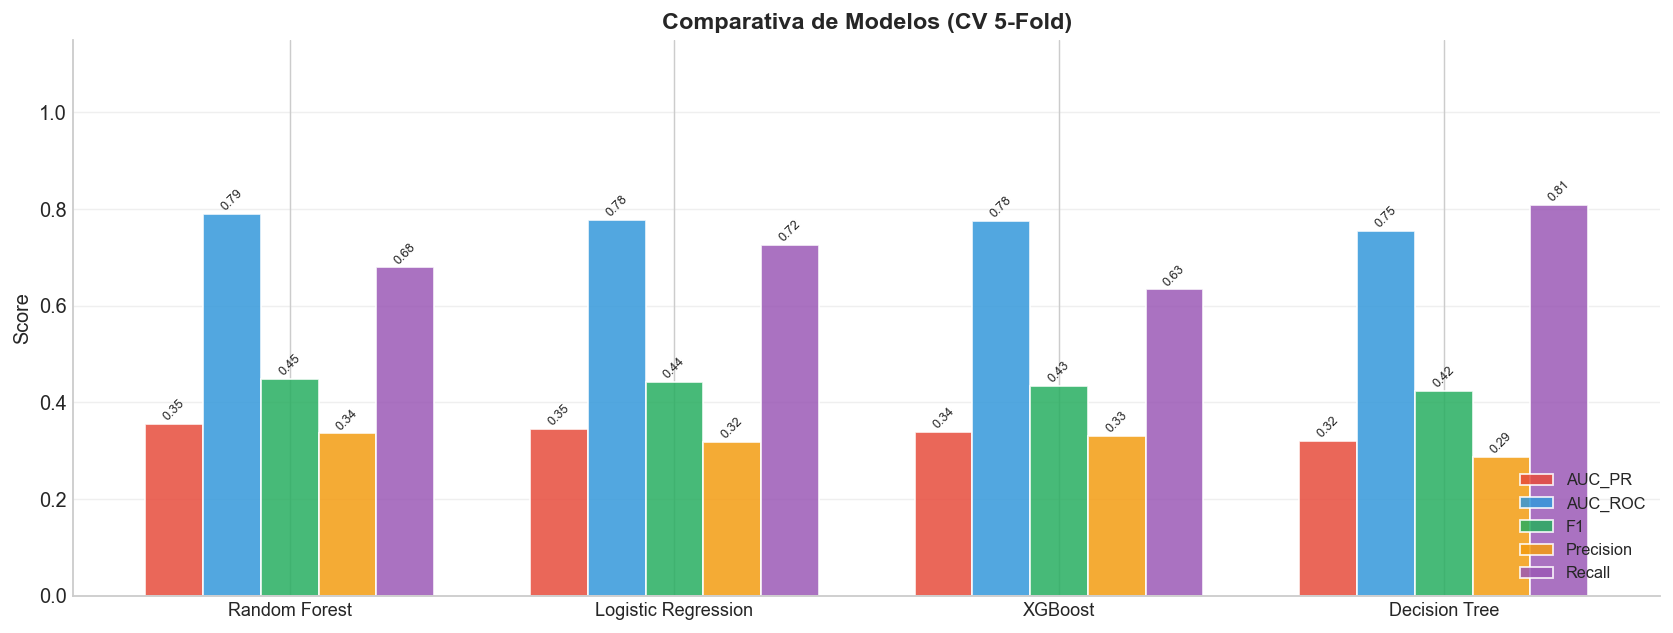


MODELO GANADOR (mejor AUC-PR): Random Forest
  AUC-PR  = 0.3546
  AUC-ROC = 0.7892


In [15]:
# --- Cross-Validation Estratificada (5-Fold) ---
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=10,
        min_samples_leaf=20, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        max_depth=15, min_samples_leaf=10,
        random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=ratio, eval_metric='aucpr',
        random_state=42, n_jobs=-1, verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'AUC_PR': 'average_precision',
    'AUC_ROC': 'roc_auc',
    'F1': 'f1',
    'Precision': 'precision',
    'Recall': 'recall',
}

results = {}
print(f'CROSS-VALIDATION ESTRATIFICADA (5-Fold, ratio {ratio:.1f}:1)')
print('=' * 65)
for name, model in models.items():
    print(f'  {name:25s}', end=' ', flush=True)
    cv_res = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=scoring, return_train_score=False, n_jobs=-1)
    results[name] = {m: cv_res[f'test_{m}'].mean() for m in scoring}
    results[name].update({f'{m}_std': cv_res[f'test_{m}'].std() for m in scoring})
    print(f'AUC-PR = {results[name]["AUC_PR"]:.4f} '
          f'(+/- {results[name]["AUC_PR_std"]:.4f})')

# Grafica comparativa
metrics_show = ['AUC_PR', 'AUC_ROC', 'F1', 'Precision', 'Recall']
rows_r = [{**{'Modelo': n}, **{m: results[n][m] for m in metrics_show}} for n in results]
results_df = pd.DataFrame(rows_r).set_index('Modelo').sort_values('AUC_PR', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_df))
width = 0.15
colors_m = [C_SI, C_BLUE, C_NO, C_WARN, C_PURP]

for i, metric in enumerate(metrics_show):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=colors_m[i], edgecolor='white', alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.2f}', ha='center', fontsize=7, rotation=45)

ax.set_title('Comparativa de Modelos (CV 5-Fold)', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

winner_name = results_df.index[0]
print(f'\nMODELO GANADOR (mejor AUC-PR): {winner_name}')
print(f'  AUC-PR  = {results_df.loc[winner_name, "AUC_PR"]:.4f}')
print(f'  AUC-ROC = {results_df.loc[winner_name, "AUC_ROC"]:.4f}')

OPTIMIZACION DEL THRESHOLD
  Threshold optimo:    0.4984  (F1 = 0.4617)
  Threshold por defecto: 0.50   (F1 = 0.4596)
  Mejora:              +0.0021
  Precision:           0.3422
  Recall:              0.7095


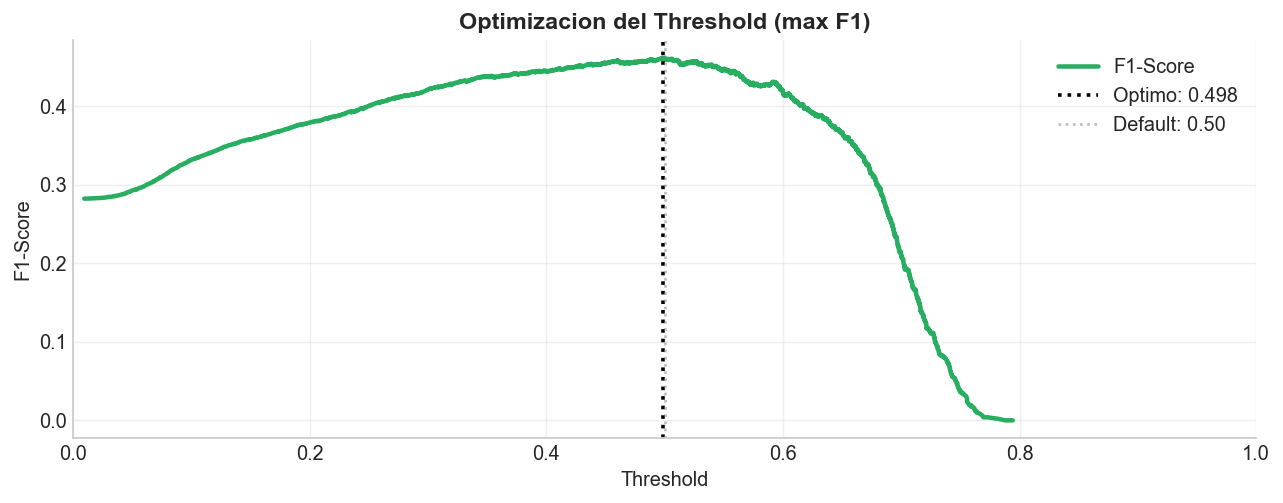

In [16]:
# --- Entrenar modelo ganador ---
winner = models[winner_name]
winner.fit(X_train, y_train)
proba_test = winner.predict_proba(X_test)[:, 1]

# --- Optimizar threshold (max F1) ---
prec, rec, thr = precision_recall_curve(y_test, proba_test)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
idx = np.argmax(f1s)
t_opt = thr[idx]
f1_opt = f1s[idx]
f1_default = f1_score(y_test, (proba_test >= 0.5).astype(int))

print('OPTIMIZACION DEL THRESHOLD')
print('=' * 50)
print(f'  Threshold optimo:    {t_opt:.4f}  (F1 = {f1_opt:.4f})')
print(f'  Threshold por defecto: 0.50   (F1 = {f1_default:.4f})')
print(f'  Mejora:              +{f1_opt - f1_default:.4f}')
print(f'  Precision:           {prec[idx]:.4f}')
print(f'  Recall:              {rec[idx]:.4f}')

# Grafica
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thr, f1s, color=C_NO, lw=2.5, label='F1-Score')
ax.axvline(t_opt, color='black', ls=':', lw=2, label=f'Optimo: {t_opt:.3f}')
ax.axvline(0.5, color='grey', ls=':', lw=1.5, alpha=0.5, label='Default: 0.50')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1-Score')
ax.set_title('Optimizacion del Threshold (max F1)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance y Evaluacion Final

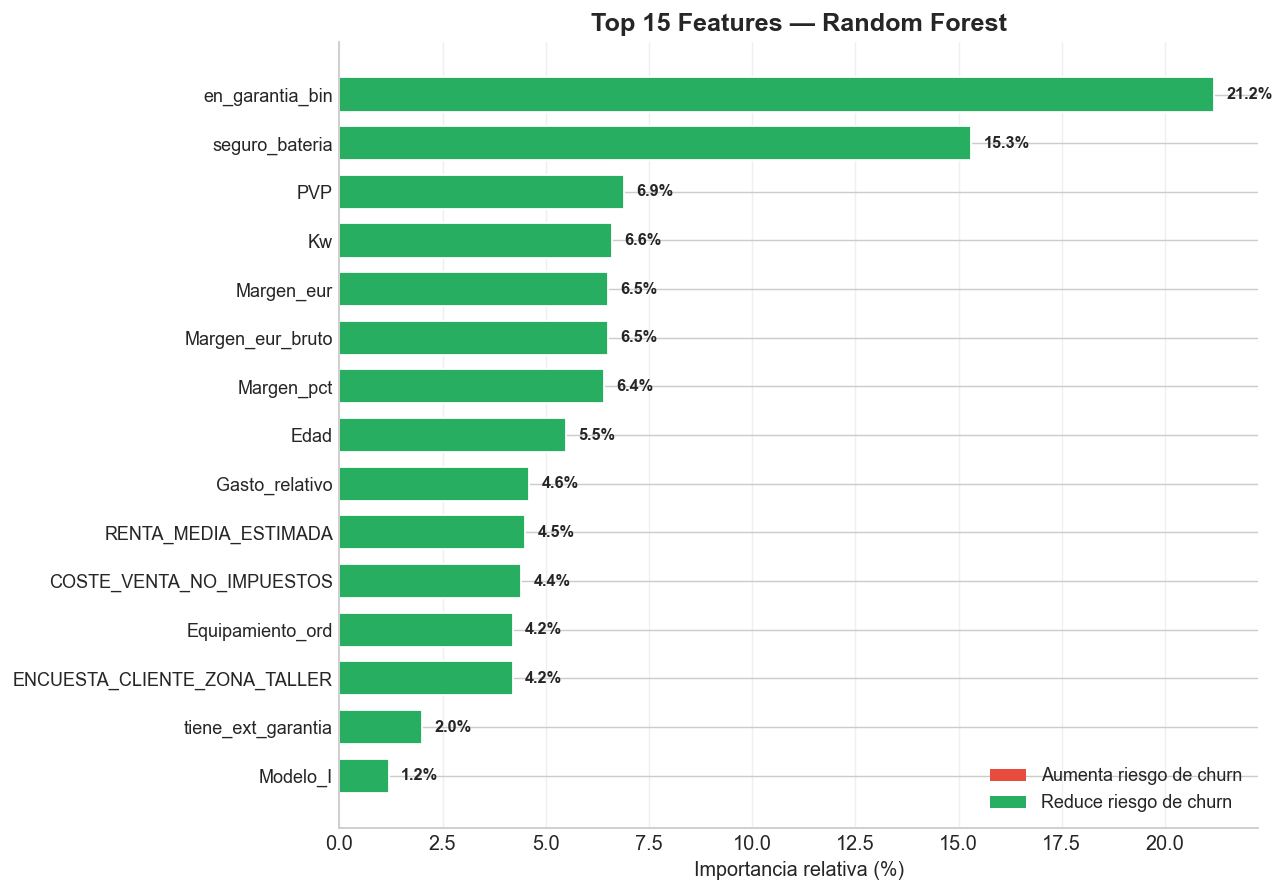


  #  Feature                         Import. (%)  Corr. Churn     Efecto
------------------------------------------------------------------------
  1  en_garantia_bin                       21.2%       -0.232     Reduce
  2  seguro_bateria                        15.3%       -0.178     Reduce
  3  PVP                                    6.9%       -0.172     Reduce
  4  Kw                                     6.6%       -0.151     Reduce
  5  Margen_eur                             6.5%       -0.042     Reduce
  6  Margen_eur_bruto                       6.5%       -0.120     Reduce
  7  Margen_pct                             6.4%       -0.029     Reduce
  8  Edad                                   5.5%       -0.070     Reduce
  9  Gasto_relativo                         4.6%       -0.068     Reduce
 10  RENTA_MEDIA_ESTIMADA                   4.5%       -0.020     Reduce
 11  COSTE_VENTA_NO_IMPUESTOS               4.4%       -0.022     Reduce
 12  Equipamiento_ord                       4.2%  

In [17]:
# --- Top 15 Features: importancia + direccion del efecto ---
if hasattr(winner, 'feature_importances_'):
    fi = pd.Series(winner.feature_importances_, index=X_train.columns)
elif hasattr(winner, 'named_steps'):
    fi = pd.Series(np.abs(winner.named_steps['clf'].coef_[0]), index=X_train.columns)

fi_top = fi.sort_values(ascending=False).head(15)
fi_pct = (fi_top / fi_top.sum() * 100).round(1)

# Direccion del efecto: correlacion con Churn
corrs = X_train[fi_top.index].corrwith(y_train)
bar_colors = [C_SI if corrs[f] > 0 else C_NO for f in fi_top.index]

# Grafica
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(fi_top) - 1, -1, -1)
bars = ax.barh(list(y_pos), fi_pct.values, color=bar_colors,
               edgecolor='white', height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(fi_top.index, fontsize=10)

for val, pos in zip(fi_pct.values, y_pos):
    ax.text(val + 0.3, pos, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C_SI, label='Aumenta riesgo de churn'),
    Patch(facecolor=C_NO, label='Reduce riesgo de churn'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='grey')

ax.set_xlabel('Importancia relativa (%)', fontsize=11)
ax.set_title(f'Top 15 Features — {winner_name}', fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla complementaria
print(f'\n{"#":>3s}  {"Feature":30s} {"Import. (%)":>12s} {"Corr. Churn":>12s} {"Efecto":>10s}')
print('-' * 72)
for i, feat in enumerate(fi_top.index, 1):
    r = corrs[feat]
    efecto = 'Aumenta' if r > 0.02 else 'Reduce' if r < -0.02 else '~'
    print(f'{i:>3d}  {feat:30s} {fi_pct[feat]:>11.1f}% {r:>+12.3f} {efecto:>10s}')

### SHAP Values (SHapley Additive exPlanations)

SHAP descompone cada prediccion individual en la contribucion de cada feature.
A diferencia de la importancia del modelo (que es global), SHAP muestra:
- **Direccion del efecto**: si un valor alto de la feature aumenta o reduce el riesgo
- **Magnitud del impacto**: cuanto influye cada feature en la prediccion
- **Interacciones**: como se combinan las features para cada cliente


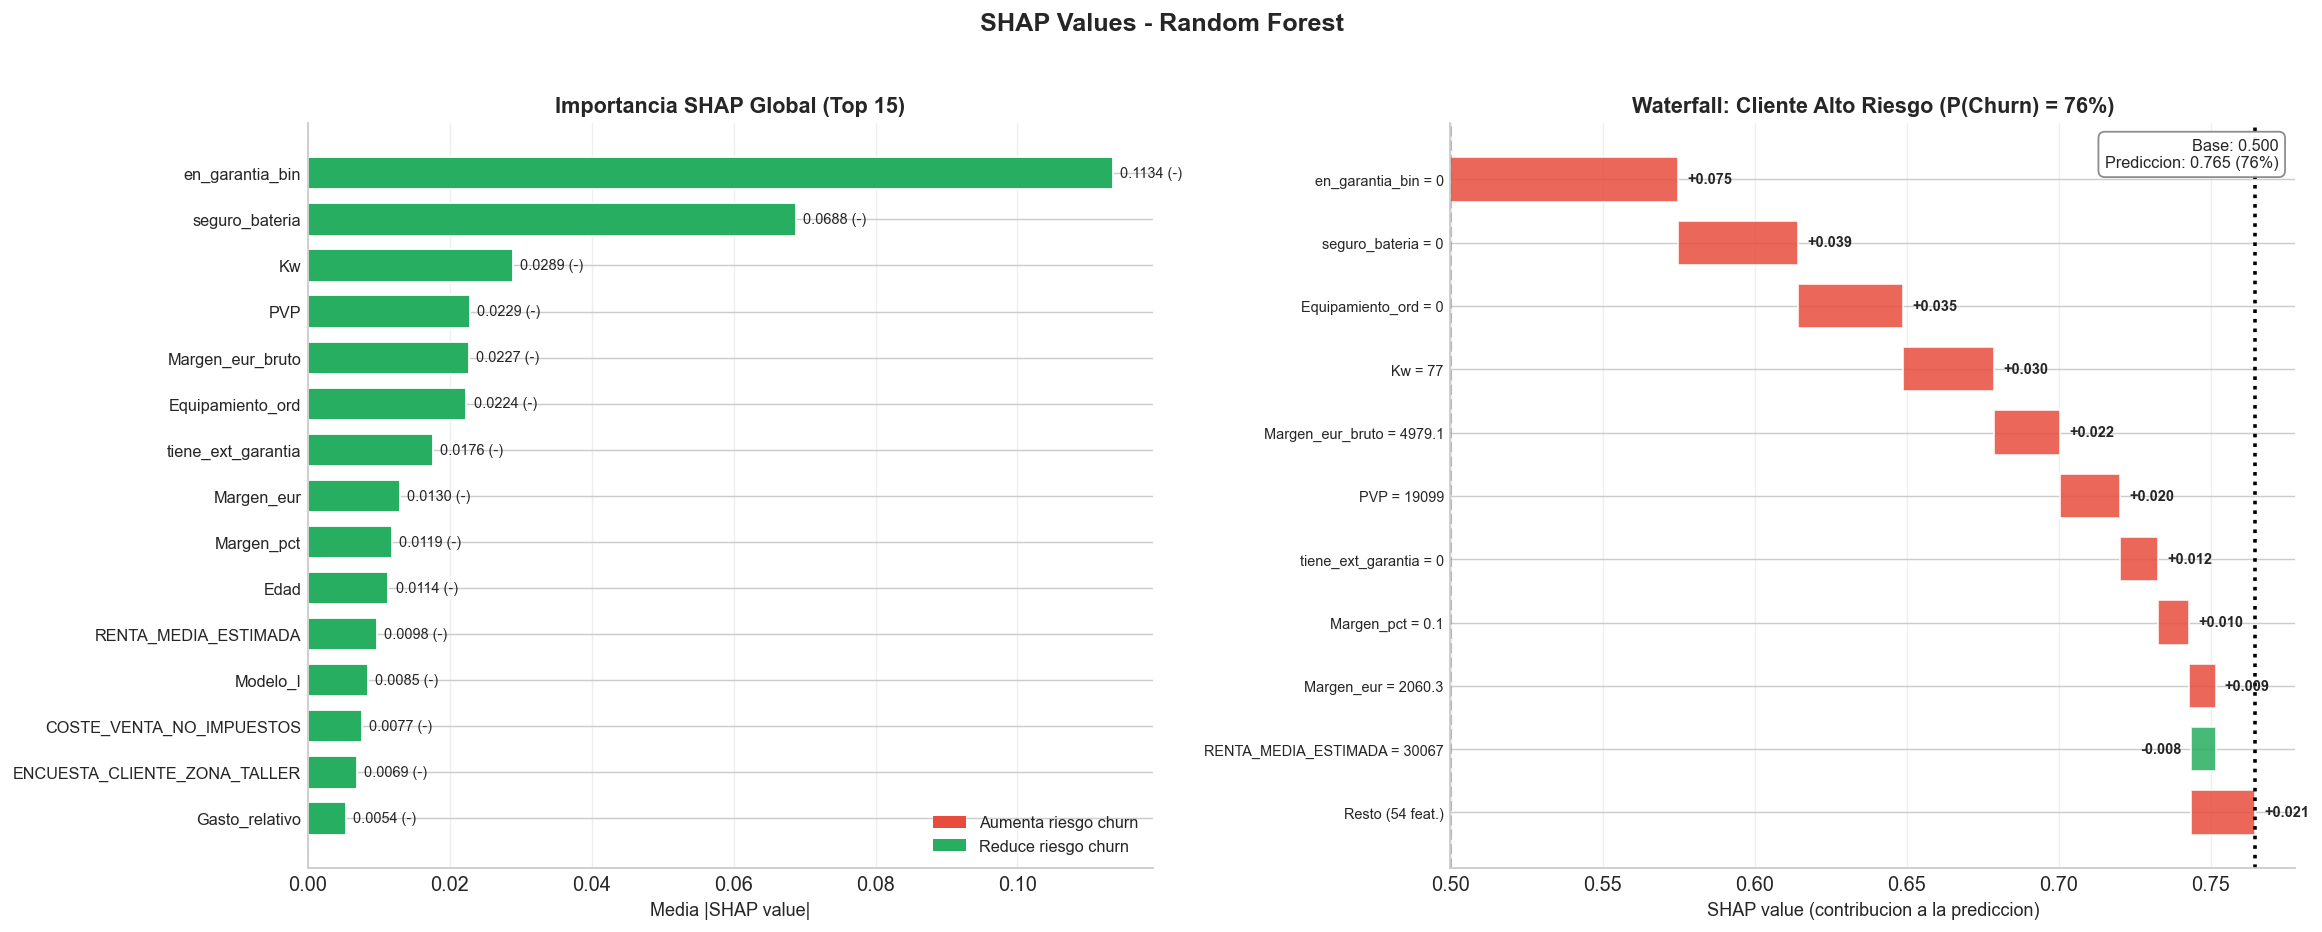

INTERPRETACION SHAP (Top 5 features)
  1. en_garantia_bin                 |SHAP| = 0.1134  (reduce riesgo)
  2. seguro_bateria                  |SHAP| = 0.0688  (reduce riesgo)
  3. Kw                              |SHAP| = 0.0289  (reduce riesgo)
  4. PVP                             |SHAP| = 0.0229  (reduce riesgo)
  5. Margen_eur_bruto                |SHAP| = 0.0227  (reduce riesgo)


In [18]:
# --- SHAP Values ---
import shap

# Calcular SHAP values con TreeExplainer
explainer = shap.TreeExplainer(winner)
shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values_raw = explainer.shap_values(shap_sample)

# Extraer SHAP de la clase positiva (Churn=1)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_vals = shap_values_raw[:, :, 1]
else:
    shap_vals = shap_values_raw

shap_df = pd.DataFrame(shap_vals, columns=shap_sample.columns, index=shap_sample.index)

# Top 15 features por importancia SHAP
shap_abs_mean = shap_df.abs().mean().sort_values(ascending=False)
top_features = shap_abs_mean.head(15).index.tolist()

# === GRAFICO: Importancia SHAP + Waterfall lado a lado ===
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel izquierdo: Importancia SHAP global (Top 15) ---
shap_top = shap_abs_mean.head(15).sort_values(ascending=True)
shap_signed = shap_df[shap_top.index].mean()
colors_shap = [C_SI if shap_signed[f] > 0 else C_NO for f in shap_top.index]

bars = axes[0].barh(range(len(shap_top)), shap_top.values,
                    color=colors_shap, edgecolor="white", height=0.7)
axes[0].set_yticks(range(len(shap_top)))
axes[0].set_yticklabels(shap_top.index, fontsize=9)
for i, v in enumerate(shap_top.values):
    sign = "+" if shap_signed[shap_top.index[i]] > 0 else "-"
    axes[0].text(v + 0.001, i, f"{v:.4f} ({sign})", va="center", fontsize=8)
axes[0].set_xlabel("Media |SHAP value|", fontsize=10)
axes[0].set_title("Importancia SHAP Global (Top 15)", fontweight="bold", fontsize=12)
axes[0].grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_shap = [Patch(facecolor=C_SI, label="Aumenta riesgo churn"),
               Patch(facecolor=C_NO, label="Reduce riesgo churn")]
axes[0].legend(handles=legend_shap, loc="lower right", fontsize=9,
               framealpha=0.9, edgecolor="grey")

# --- Panel derecho: Waterfall de un cliente de alto riesgo ---
proba_sample = winner.predict_proba(shap_sample)[:, 1]
idx_max_risk = np.argmax(proba_sample)
cliente_shap = shap_df.iloc[idx_max_risk]
cliente_features = shap_sample.iloc[idx_max_risk]
prob_cliente = proba_sample[idx_max_risk]

# Top 10 features mas influyentes para este cliente
top_k = 10
abs_vals = cliente_shap.abs().sort_values(ascending=False)
top_feats = abs_vals.head(top_k).index.tolist()

# Base value del explainer
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

# Preparar datos waterfall
labels = []
values = []
for feat in top_feats:
    val_feat = cliente_features[feat]
    if val_feat == int(val_feat):
        labels.append(f"{feat} = {int(val_feat)}")
    else:
        labels.append(f"{feat} = {val_feat:.1f}")
    values.append(cliente_shap[feat])
labels.append(f"Resto ({len(cliente_shap) - top_k} feat.)")
values.append(cliente_shap.drop(top_feats).sum())

# Calcular posiciones de cascada (de arriba a abajo)
running = base_value
starts = []
for v in values:
    starts.append(running)
    running += v

# Invertir para dibujar de abajo a arriba
labels_rev = labels[::-1]
values_rev = values[::-1]
starts_rev = starts[::-1]

for i, (lbl, val, start) in enumerate(zip(labels_rev, values_rev, starts_rev)):
    color = C_SI if val > 0 else C_NO
    axes[1].barh(i, val, left=start, color=color, edgecolor="white", height=0.7, alpha=0.85)
    side = start + val + 0.003 if val > 0 else start + val - 0.003
    ha = "left" if val > 0 else "right"
    axes[1].text(side, i, f"{val:+.3f}", va="center", ha=ha, fontsize=8, fontweight="bold")

axes[1].axvline(base_value, color="grey", ls="--", lw=1.5, alpha=0.6)
axes[1].axvline(running, color="black", ls=":", lw=2)

# Leyenda manual
axes[1].text(0.98, 0.98, f"Base: {base_value:.3f}\nPrediccion: {running:.3f} ({prob_cliente:.0%})",
             transform=axes[1].transAxes, fontsize=9, va="top", ha="right",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="grey", alpha=0.9))

axes[1].set_yticks(range(len(labels_rev)))
axes[1].set_yticklabels(labels_rev, fontsize=8)
axes[1].set_xlabel("SHAP value (contribucion a la prediccion)", fontsize=10)
axes[1].set_title(f"Waterfall: Cliente Alto Riesgo (P(Churn) = {prob_cliente:.0%})",
                  fontweight="bold", fontsize=12)
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle(f"SHAP Values - {winner_name}",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Interpretacion
print("INTERPRETACION SHAP (Top 5 features)")
print("=" * 65)
for i, feat in enumerate(top_features[:5], 1):
    mean_shap = float(shap_df[feat].mean())
    abs_shap = float(shap_df[feat].abs().mean())
    direction = "aumenta" if mean_shap > 0 else "reduce"
    print(f"  {i}. {feat:30s}  |SHAP| = {abs_shap:.4f}  ({direction} riesgo)")


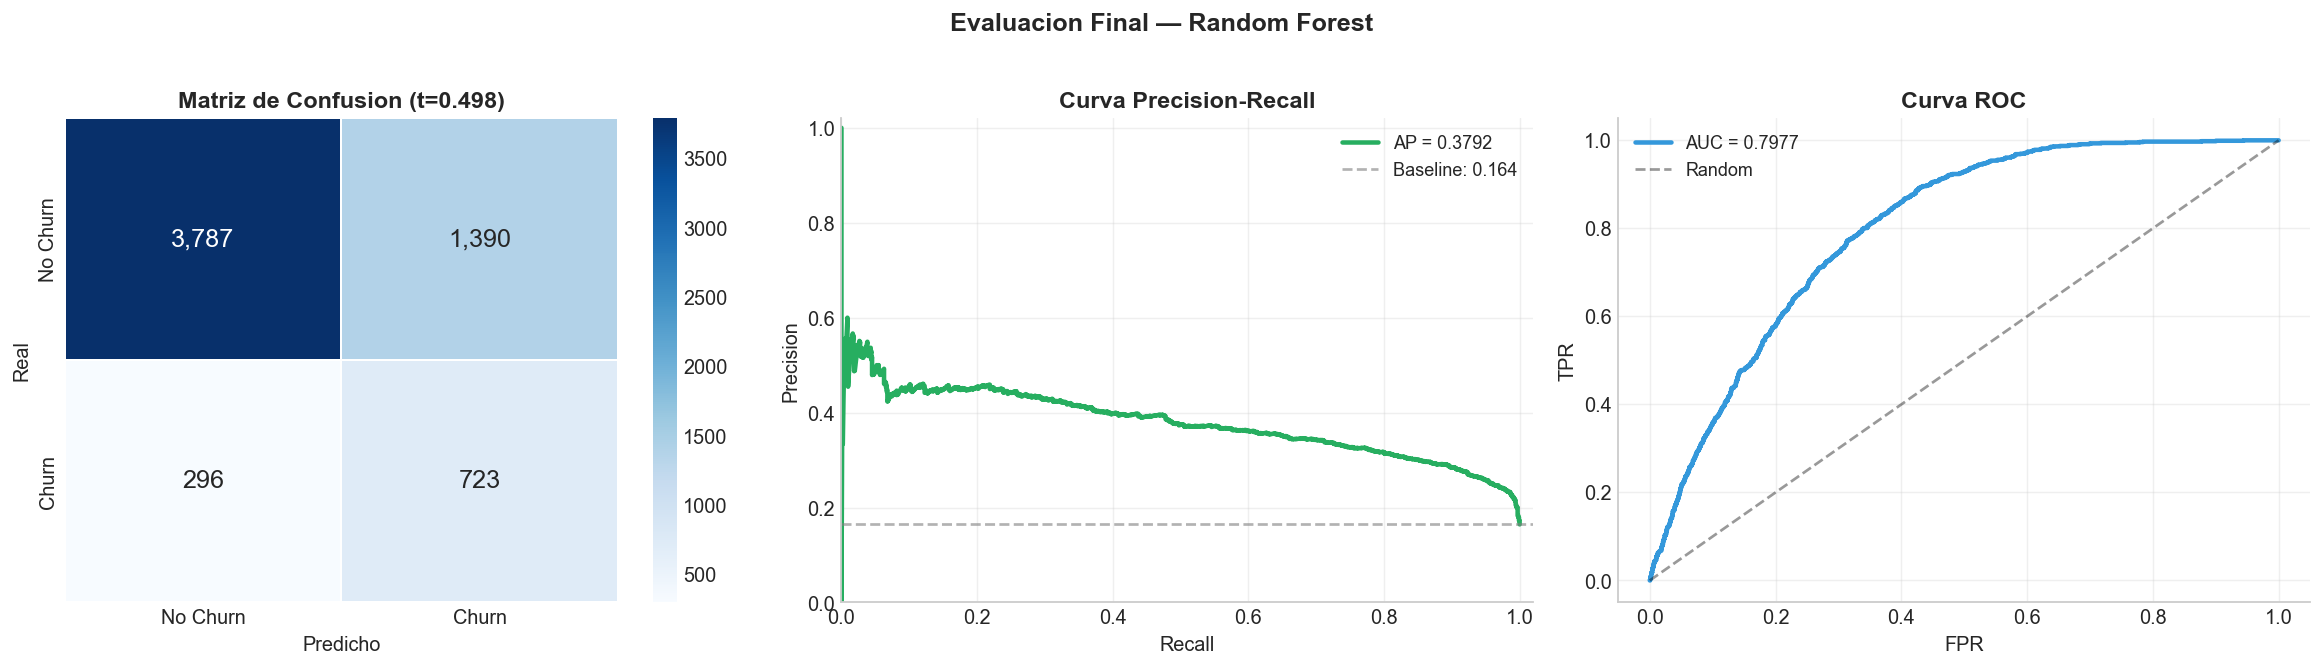

Random Forest (threshold = 0.4984)
              precision    recall  f1-score   support

    No Churn       0.93      0.73      0.82      5177
       Churn       0.34      0.71      0.46      1019

    accuracy                           0.73      6196
   macro avg       0.63      0.72      0.64      6196
weighted avg       0.83      0.73      0.76      6196



In [19]:
# --- Evaluacion final en Test ---
y_pred = (proba_test >= t_opt).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=1, linecolor='white', annot_kws={'size': 14})
axes[0].set_title(f'Matriz de Confusion (t={t_opt:.3f})', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

# 2. Curva Precision-Recall
p, r, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
axes[1].plot(r, p, color=C_NO, lw=2.5, label=f'AP = {ap:.4f}')
axes[1].axhline(y_test.mean(), color='grey', ls='--', alpha=0.6,
                label=f'Baseline: {y_test.mean():.3f}')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1.02); axes[1].set_ylim(0, 1.02)

# 3. Curva ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
auc_val = roc_auc_score(y_test, proba_test)
axes[2].plot(fpr, tpr, color=C_BLUE, lw=2.5, label=f'AUC = {auc_val:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[2].set_title('Curva ROC', fontweight='bold')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].legend(fontsize=10); axes[2].grid(alpha=0.3)

plt.suptitle(f'Evaluacion Final — {winner_name}',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Classification report
print(f'{winner_name} (threshold = {t_opt:.4f})')
print('=' * 55)
print(classification_report(y_test, y_pred,
                            target_names=['No Churn', 'Churn']))

---
## 9. Staging (Produccion)

Se aplica el pipeline completo a `nuevos_clientes.csv` (10.000 clientes nuevos):
1. Limpieza + Feature Engineering identico al sandbox
2. Alineacion de columnas con el set de entrenamiento
3. Data drift check
4. Prediccion + segmentacion de riesgo

In [20]:
# --- Cargar y transformar datos frescos ---
df_staging = pd.read_csv("nuevos_clientes.csv")
df_staging = limpiar_datos(df_staging)

# Variables temporales
df_staging["Sales_Date"] = pd.to_datetime(df_staging["Sales_Date"])
df_staging["FIN_GARANTIA"] = pd.to_datetime(df_staging["FIN_GARANTIA"])
df_staging["BASE_DATE"] = pd.to_datetime(df_staging["BASE_DATE"])
df_staging["Antiguedad_dias"] = (df_staging["BASE_DATE"] - df_staging["Sales_Date"]).dt.days
df_staging["Dias_fin_garantia"] = (df_staging["FIN_GARANTIA"] - df_staging["BASE_DATE"]).dt.days

# Merge con costes (temporal, para features derivadas)
costes = pd.read_csv("Costes.csv")
df_staging = df_staging.merge(costes, on="Modelo", how="left")

# Mismas features derivadas que sandbox
df_staging["Margen_pct"] = df_staging["Margen_eur"] / df_staging["PVP"]
df_staging["Gasto_relativo"] = np.where(df_staging["RENTA_MEDIA_ESTIMADA"] > 0,
                                        df_staging["PVP"] / df_staging["RENTA_MEDIA_ESTIMADA"], 0)
ant_s = (df_staging["Antiguedad_dias"] / 365.25).clip(lower=1/365.25)
df_staging["Revisiones_por_ano"] = df_staging["Revisiones"] / ant_s
df_staging["perfil_cliente"] = (df_staging["Revisiones"] == 0).astype(int)
df_staging["tiene_datos_demo"] = ((df_staging["RENTA_MEDIA_ESTIMADA"] > 0) | (df_staging["ENCUESTA_CLIENTE_ZONA_TALLER"] > 0)).astype(int)
df_staging["tiene_ext_garantia"] = (df_staging["EXTENSION_GARANTIA"] != "NO").astype(int)
df_staging["en_garantia_bin"] = (df_staging["EN_GARANTIA"] == "SI").astype(int)
df_staging["mant_pendiente"] = (df_staging["MANTENIMIENTO_GRATUITO"] > df_staging["Revisiones"]).astype(int)
df_staging["seguro_bateria"] = (df_staging["SEGURO_BATERIA_LARGO_PLAZO"] == "SI").astype(int)
df_staging["es_particular"] = (df_staging["MOTIVO_VENTA"] == "Particular").astype(int)
df_staging["origen_tienda"] = (df_staging["Origen"] == "Tienda").astype(int)
df_staging["fuel_electrico"] = (df_staging["Fuel"] == "ELECTRICO").astype(int)
df_staging["tiene_descuento"] = (df_staging["COSTE_VENTA_NO_IMPUESTOS"] > 0).astype(int)

# Encoding
df_staging["Equipamiento_ord"] = df_staging["Equipamiento"].map({"Low": 0, "Mid": 1, "Mid-High": 2, "High": 3})
df_staging = df_staging.drop(columns=["Equipamiento"])
ohe_cols_s = ["GENERO", "QUEJA", "ZONA", "FORMA_PAGO", "Modelo", "TIENDA_DESC", "STATUS_SOCIAL"]
ohe_cols_s = [c for c in ohe_cols_s if c in df_staging.columns]
df_staging = pd.get_dummies(df_staging, columns=ohe_cols_s, drop_first=True, dtype=int)

# Eliminar columnas (identificadores, fechas, leakage, costes de venta, staging-only)
cols_drop_s = [
    # Identificadores
    "CODE", "Id_Producto", "Customer_ID",
    # Fechas (info ya extraida)
    "Sales_Date", "FIN_GARANTIA", "BASE_DATE",
    # Categoricas ya sustituidas por flags/OHE
    "TRANSMISION_ID", "TIPO_CARROCERIA", "PROV_DESC", "Fuel",
    "MOTIVO_VENTA", "Origen", "EN_GARANTIA", "SEGURO_BATERIA_LARGO_PLAZO",
    "EXTENSION_GARANTIA",
    # Alta cardinalidad sin valor
    "CODIGO_POSTAL",
    # Costes de venta (no son features)
    "Costetransporte", "Margendistribuidor", "GastosMarketing",
    "Mantenimiento_medio", "Comisi\u00f3n_Marca", "Margen",
    # Solo en staging / target
    "Lead_compra_1", "Churn_400", "Churn",
    # Quasi-leakage (excluidas del modelo)
    "Revisiones", "Revisiones_por_ano", "perfil_cliente",
    "Km_medio_por_revision", "km_ultima_revision",
    "Antiguedad_dias", "Dias_fin_garantia", "mant_pendiente",
]
df_staging = df_staging.drop(columns=[c for c in cols_drop_s if c in df_staging.columns])

# Alinear columnas con train
for c in set(X_train.columns) - set(df_staging.columns):
    df_staging[c] = 0
extra = [c for c in df_staging.columns if c not in X_train.columns]
if extra:
    df_staging = df_staging.drop(columns=extra)
X_staging = df_staging[X_train.columns]

print("STAGING: PIPELINE COMPLETADO")
print("=" * 50)
print(f"  Registros:           {len(X_staging):,}")
print(f"  Features alineadas:  {X_staging.shape[1]}")
if extra:
    print(f"  Cols extra eliminadas: {len(extra)}")

STAGING: PIPELINE COMPLETADO
  Registros:           10,000
  Features alineadas:  64


In [21]:
# --- Data Drift Check ---
drift_rows = []
for col in X_staging.columns:
    if X_train[col].std() == 0: continue
    drift = abs(X_staging[col].mean() - X_train[col].mean()) / X_train[col].std()
    drift_rows.append({'Feature': col, 'Drift (sigmas)': round(drift, 2)})

drift_df = pd.DataFrame(drift_rows).sort_values('Drift (sigmas)', ascending=False)
n_alto = (drift_df['Drift (sigmas)'] > 1.0).sum()

print(f'DATA DRIFT: {n_alto} / {len(drift_df)} features con drift > 1 sigma')
if n_alto > len(drift_df) * 0.3:
    print('ALERTA: drift significativo.')
else:
    print('Drift aceptable.')

print(f'\nTop 10 features con mayor drift:')
for _, row in drift_df.head(10).iterrows():
    print(f'  {row["Feature"]:35s} {row["Drift (sigmas)"]:.2f} sigmas')

DATA DRIFT: 0 / 63 features con drift > 1 sigma
Drift aceptable.

Top 10 features con mayor drift:
  en_garantia_bin                     0.85 sigmas
  QUEJA_SIN_REGISTRO                  0.85 sigmas
  MANTENIMIENTO_GRATUITO              0.76 sigmas
  Modelo_H                            0.66 sigmas
  QUEJA_SI                            0.44 sigmas
  tiene_datos_demo                    0.24 sigmas
  FORMA_PAGO_Financiera Marca         0.20 sigmas
  STATUS_SOCIAL_DESCONOCIDO           0.20 sigmas
  RENTA_MEDIA_ESTIMADA                0.19 sigmas
  seguro_bateria                      0.17 sigmas


PREDICCIONES STAGING
  Segmento                    Clientes    % Total  Prob. media
  ---------------------------------------------------------
  Bajo (<30%)                    6,241      62.4%        12.8%
  Medio (30%-50%)                2,060      20.6%        39.9%
  Alto (>=50%)                   1,699      17.0%        59.1%
  TOTAL                         10,000

CHURN PREDICHO POR MODELO
  Modelo    Clientes  Prob media  Churn pred    Tasa
  ------------------------------------------------
  A          1,277.0       49.3%         712   55.8%
  G              7.0       36.5%           0    0.0%
  C            705.0       35.1%         117   16.6%
  B          2,779.0       33.5%         666   24.0%
  E            118.0       29.8%           7    5.9%
  D          1,547.0       26.7%         197   12.7%
  F              2.0       26.0%           0    0.0%
  H            473.0       21.7%           0    0.0%
  K             16.0       18.0%           0    0.0%
  J            451.0

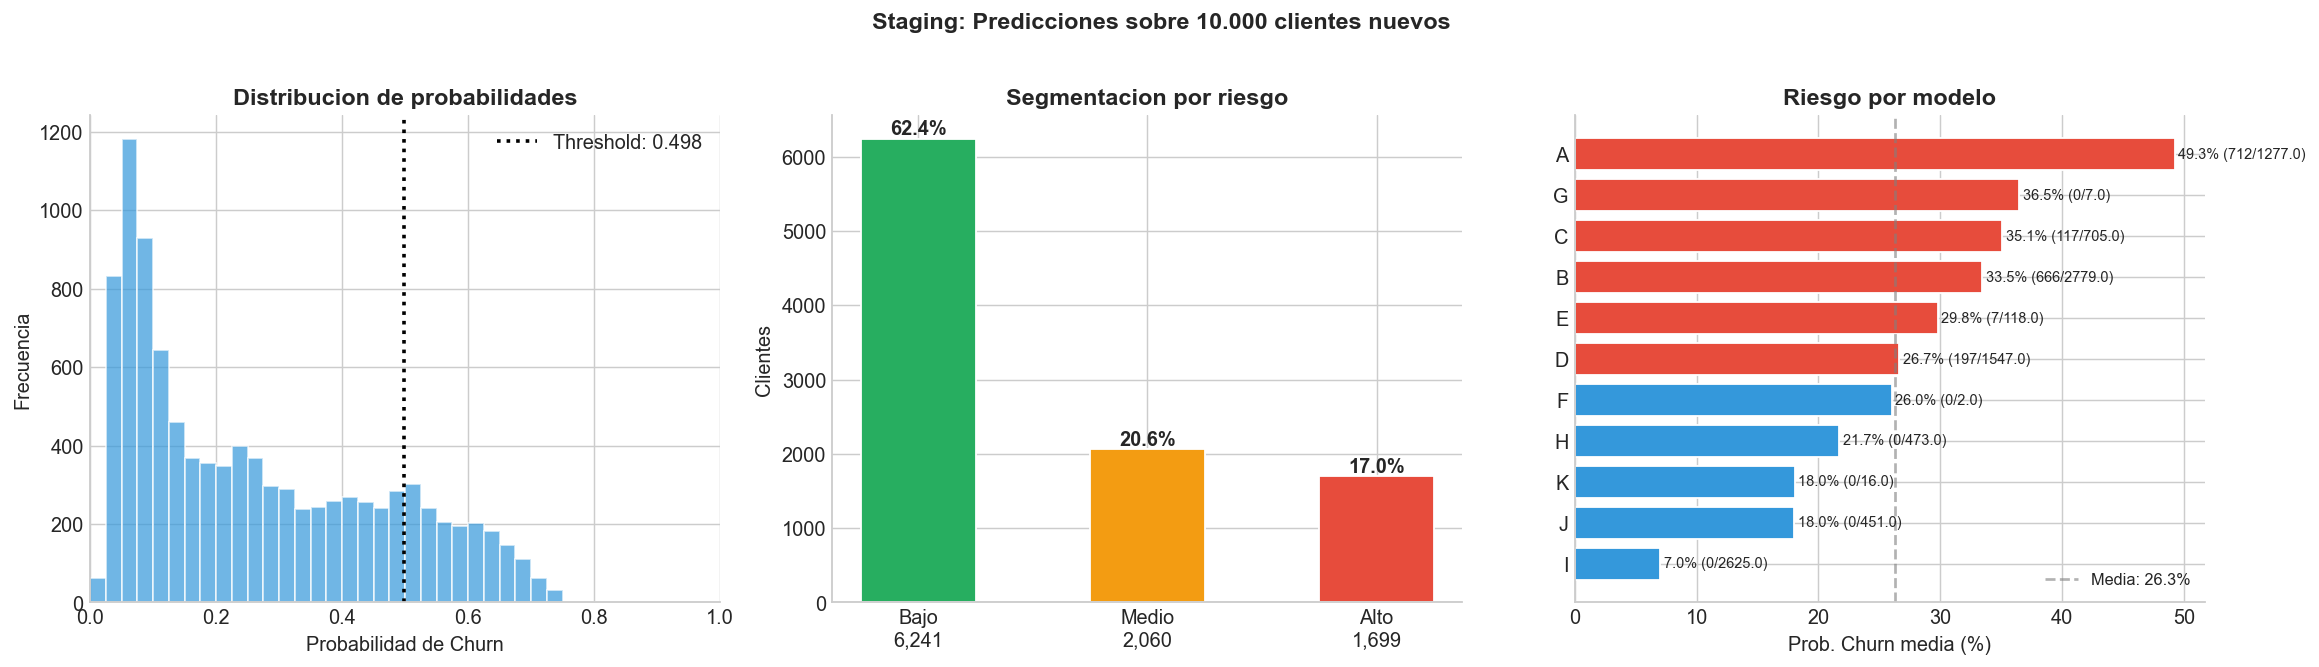


Exportado: predicciones_staging.csv (10,000 registros)


In [22]:
# --- Predicciones ---
proba_staging = winner.predict_proba(X_staging)[:, 1]
pred_staging = (proba_staging >= t_opt).astype(int)

# Segmentos de riesgo
riesgo_bajo = (proba_staging < 0.3).sum()
riesgo_medio = ((proba_staging >= 0.3) & (proba_staging < t_opt)).sum()
riesgo_alto = (proba_staging >= t_opt).sum()

print("PREDICCIONES STAGING")
print("=" * 60)
print(f'  {"Segmento":<25s} {"Clientes":>10s} {"% Total":>10s} {"Prob. media":>12s}')
print("  " + "-" * 57)
for seg, n, mask in [
    (f"Bajo (<30%)", riesgo_bajo, proba_staging < 0.3),
    (f"Medio (30%-{t_opt:.0%})", riesgo_medio, (proba_staging >= 0.3) & (proba_staging < t_opt)),
    (f"Alto (>={t_opt:.0%})", riesgo_alto, proba_staging >= t_opt),
]:
    pm = proba_staging[mask].mean() if mask.sum() > 0 else 0
    print(f"  {seg:<25s} {n:>10,} {n/len(proba_staging):>10.1%} {pm:>12.1%}")
print(f'  {"TOTAL":<25s} {len(proba_staging):>10,}')

# Resumen por modelo
df_orig_s = pd.read_csv("nuevos_clientes.csv")
res_modelo = pd.DataFrame({
    "Modelo": df_orig_s["Modelo"],
    "Prob": proba_staging,
    "Pred": pred_staging,
})
res_mod = res_modelo.groupby("Modelo").agg(
    Clientes=("Modelo", "count"),
    Prob_media=("Prob", "mean"),
    Churn_pred=("Pred", "sum"),
).sort_values("Prob_media", ascending=False)
res_mod["Tasa_churn"] = (res_mod["Churn_pred"] / res_mod["Clientes"] * 100).round(1)

print("\nCHURN PREDICHO POR MODELO")
print("=" * 60)
print(f'  {"Modelo":<8s} {"Clientes":>9s} {"Prob media":>11s} {"Churn pred":>11s} {"Tasa":>7s}')
print("  " + "-" * 48)
for mod, row in res_mod.iterrows():
    print(f'  {mod:<8s} {row["Clientes"]:>9,} {row["Prob_media"]:>11.1%} {row["Churn_pred"]:>11,.0f} {row["Tasa_churn"]:>6.1f}%')

# Graficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de probabilidades
bins = np.linspace(0, 1, 41)
axes[0].hist(proba_staging, bins=bins, color=C_BLUE, alpha=0.7, edgecolor="white")
axes[0].axvline(t_opt, color="black", ls=":", lw=2, label=f"Threshold: {t_opt:.3f}")
axes[0].set_title("Distribucion de probabilidades", fontweight="bold")
axes[0].set_xlabel("Probabilidad de Churn"); axes[0].set_ylabel("Frecuencia")
axes[0].legend(); axes[0].set_xlim(0, 1)

# 2. Segmentacion por riesgo
labels = [f"Bajo\n{riesgo_bajo:,}", f"Medio\n{riesgo_medio:,}", f"Alto\n{riesgo_alto:,}"]
sizes = [riesgo_bajo, riesgo_medio, riesgo_alto]
colors_r = [C_NO, C_WARN, C_SI]
bars = axes[1].bar(labels, sizes, color=colors_r, edgecolor="white", width=0.5)
for bar, v in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 50,
                 f"{v/len(proba_staging):.1%}", ha="center", fontweight="bold")
axes[1].set_title("Segmentacion por riesgo", fontweight="bold")
axes[1].set_ylabel("Clientes")

# 3. Churn predicho por modelo
churn_mod = res_mod.sort_values("Prob_media", ascending=True)
colores_mod = [C_SI if v > proba_staging.mean() else C_BLUE for v in churn_mod["Prob_media"]]
axes[2].barh(churn_mod.index, churn_mod["Prob_media"] * 100, color=colores_mod, edgecolor="white")
axes[2].axvline(proba_staging.mean() * 100, color="grey", ls="--", alpha=0.6,
                label=f"Media: {proba_staging.mean():.1%}")
for i, (mod, row) in enumerate(churn_mod.iterrows()):
    axes[2].text(row["Prob_media"] * 100 + 0.3, i,
                 f'{row["Prob_media"]:.1%} ({row["Churn_pred"]:.0f}/{row["Clientes"]})',
                 va="center", fontsize=8)
axes[2].set_xlabel("Prob. Churn media (%)")
axes[2].set_title("Riesgo por modelo", fontweight="bold")
axes[2].legend(fontsize=9)

plt.suptitle("Staging: Predicciones sobre 10.000 clientes nuevos",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Exportar
resultados = pd.DataFrame({
    "Customer_ID": df_orig_s["Customer_ID"],
    "Modelo": df_orig_s["Modelo"],
    "Probabilidad_Churn": proba_staging.round(4),
    "Prediccion_Churn": pred_staging,
    "Riesgo": pd.cut(proba_staging, bins=[0, 0.3, t_opt, 1.0],
                     labels=["Bajo", "Medio", "Alto"], include_lowest=True),
})
resultados.to_csv("predicciones_staging.csv", index=False)
print(f"\nExportado: predicciones_staging.csv ({len(resultados):,} registros)")

---
## 10. Estrategia Comercial

### Modelo economico

El ingreso por revision se proyecta con capitalizacion compuesta:

$$C(n) = \text{BASE} \cdot (1 + \alpha)^n$$

**Costes por revision de taller** (se deducen del ingreso C(n)):

| Concepto | Valor |
|----------|-------|
| Marketing variable | 1% de C(n) |
| Comision marca | Segun modelo (2%-8%, de `Costes.csv`) |

**Costes de la venta del vehiculo** (NO se aplican por revision):
`Costetransporte`, `Margendistribuidor`, `GastosMarketing` son costes one-shot de la operacion de venta.

| Parametro | Valor |
|-----------|-------|
| $\alpha$ modelos premium (A, B) | 7% |
| $\alpha$ resto de modelos | 10% |
| Margen minimo total | 37% (30% concesionario + 7% marca) |

### Business Rules

Se definen **4 tipos de accion comercial** asignados automaticamente segun el perfil de cada cliente.
La asignacion se basa en reglas de negocio que combinan el **nivel de riesgo** (probabilidad
de churn) y el **valor economico** (CLTV).


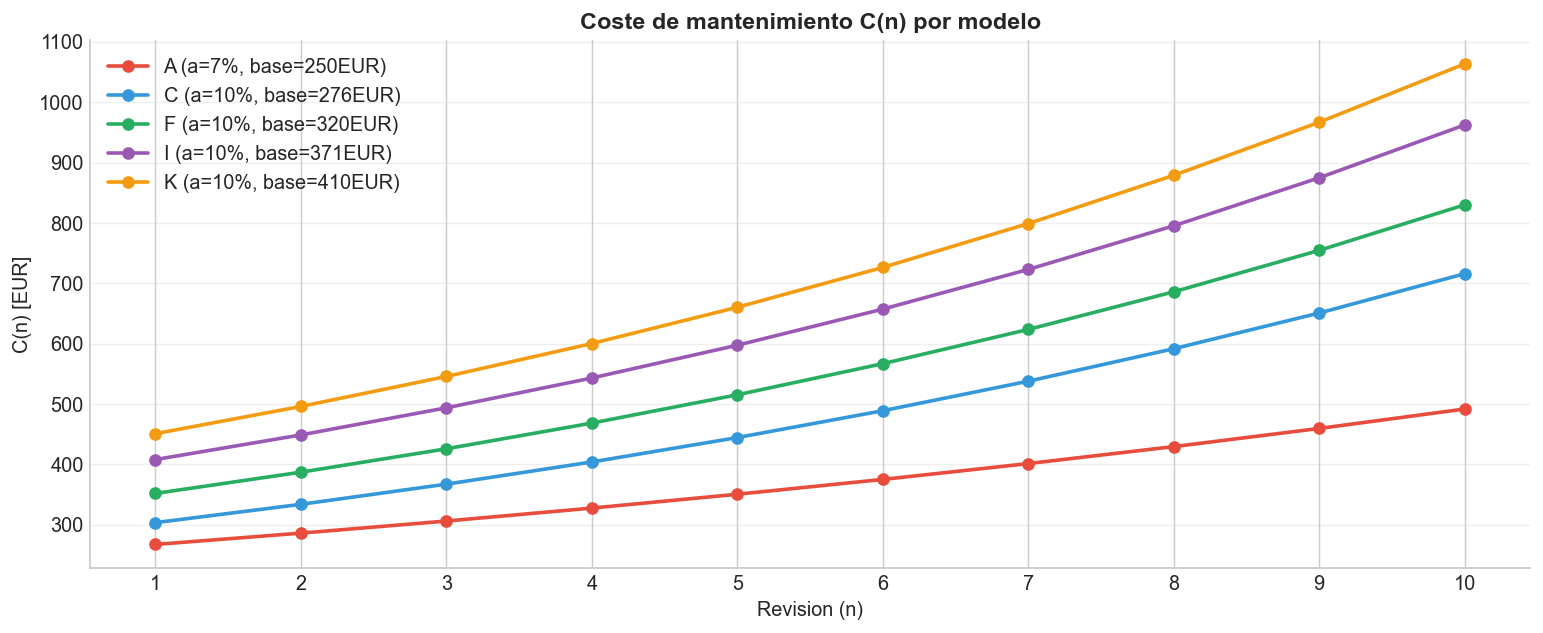

ESTRUCTURA DE COSTES POR REVISION DE TALLER
  Mod   BASE  alpha     C(1)   Mkt 1%  Com.Marca Margen br.
  -----------------------------------------------------------------
    A    250     7%      268      2.7       5.3 (2%)      259EUR (97%)
    B    263     7%      281      2.8       5.6 (2%)      273EUR (97%)
    C    276    10%      304      3.0      15.2 (5%)      285EUR (94%)
    D    290    10%      319      3.2      15.9 (5%)      300EUR (94%)
    E    305    10%      336      3.4      16.8 (5%)      315EUR (94%)
    F    320    10%      352      3.5      17.6 (5%)      331EUR (94%)
    G    336    10%      370      3.7      18.5 (5%)      347EUR (94%)
    H    353    10%      388      3.9      19.4 (5%)      365EUR (94%)
    I    371    10%      408      4.1      32.6 (8%)      371EUR (91%)
    J    390    10%      429      4.3      34.3 (8%)      390EUR (91%)
    K    410    10%      451      4.5      36.1 (8%)      410EUR (91%)


In [23]:
# === 10.1 Datos base y C(n) ===

costes = pd.read_csv("Costes.csv")
costes["alpha"] = costes["Modelo"].apply(lambda m: 0.07 if m in ["A", "B"] else 0.10)

# Construir tabla de negocio por cliente
df_orig = pd.read_csv("nuevos_clientes.csv")
df_biz = pd.DataFrame({
    "Customer_ID": df_orig["Customer_ID"],
    "Modelo": df_orig["Modelo"],
    "Revisiones": df_orig["Revisiones"],
    "PVP": df_orig["PVP"],
    "Prob_Churn": proba_staging.round(4),
    "Riesgo": pd.cut(proba_staging, bins=[0, 0.3, t_opt, 1.0],
                     labels=["Bajo", "Medio", "Alto"], include_lowest=True),
})
df_biz = df_biz.merge(costes, on="Modelo", how="left")

# C(n) de la proxima revision para cada cliente
df_biz["n_prox"] = df_biz["Revisiones"] + 1
df_biz["C_n"] = df_biz["Mantenimiento_medio"] * (1 + df_biz["alpha"]) ** df_biz["n_prox"]

# Costes operativos por revision de taller
# NOTA: Costetransporte, Margendistribuidor y GastosMarketing son costes de la VENTA del vehiculo,
# no del mantenimiento. Por revision solo aplican:
df_biz["Coste_mkt_var"] = df_biz["C_n"] * 0.01                             # 1% marketing variable
df_biz["Coste_marca"] = df_biz["C_n"] * df_biz["Comisión_Marca"] / 100  # Comision marca (2-8%)

# Costes totales operativos por revision (sin campana)
df_biz["Costes_op"] = df_biz["Coste_mkt_var"] + df_biz["Coste_marca"]

# Margen bruto (antes de campana)
df_biz["Margen_bruto"] = df_biz["C_n"] - df_biz["Costes_op"]
df_biz["Margen_bruto_pct"] = df_biz["Margen_bruto"] / df_biz["C_n"]

# Grafica C(n)
fig, ax = plt.subplots(figsize=(12, 5))
modelos_repr = ["A", "C", "F", "I", "K"]
col_mod = {"A": C_SI, "C": C_BLUE, "F": C_NO, "I": C_PURP, "K": C_WARN}
rows_cn = []
for _, r in costes.iterrows():
    for n in range(1, 11):
        rows_cn.append({"Modelo": r["Modelo"], "n": n,
                        "C_n": r["Mantenimiento_medio"] * (1 + r["alpha"]) ** n})
df_cn = pd.DataFrame(rows_cn)
for modelo in modelos_repr:
    sub = df_cn[df_cn["Modelo"] == modelo]
    info = costes[costes["Modelo"] == modelo].iloc[0]
    ax.plot(sub["n"], sub["C_n"], marker="o", lw=2, color=col_mod[modelo],
            label=f"{modelo} (a={info['alpha']:.0%}, base={info['Mantenimiento_medio']:.0f}EUR)")
ax.set_xlabel("Revision (n)"); ax.set_ylabel("C(n) [EUR]")
ax.set_title("Coste de mantenimiento C(n) por modelo", fontweight="bold")
ax.legend(loc="upper left"); ax.set_xticks(range(1, 11)); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("ESTRUCTURA DE COSTES POR REVISION DE TALLER")
print("=" * 70)
print(f'  {"Mod":>3s} {"BASE":>6s} {"alpha":>6s} {"C(1)":>8s} {"Mkt 1%":>8s} {"Com.Marca":>10s} {"Margen br.":>10s}')
print("  " + "-" * 65)
for _, r in costes.iterrows():
    c1 = r["Mantenimiento_medio"] * (1 + r["alpha"])
    mkt = c1 * 0.01
    com = c1 * r["Comisión_Marca"] / 100
    mb = c1 - mkt - com
    print(f'  {r["Modelo"]:>3s} {r["Mantenimiento_medio"]:>6.0f} {r["alpha"]:>6.0%} {c1:>8.0f} {mkt:>8.1f} {com:>9.1f} ({r["Comisión_Marca"]:.0f}%) {mb:>8.0f}EUR ({mb/c1:.0%})')

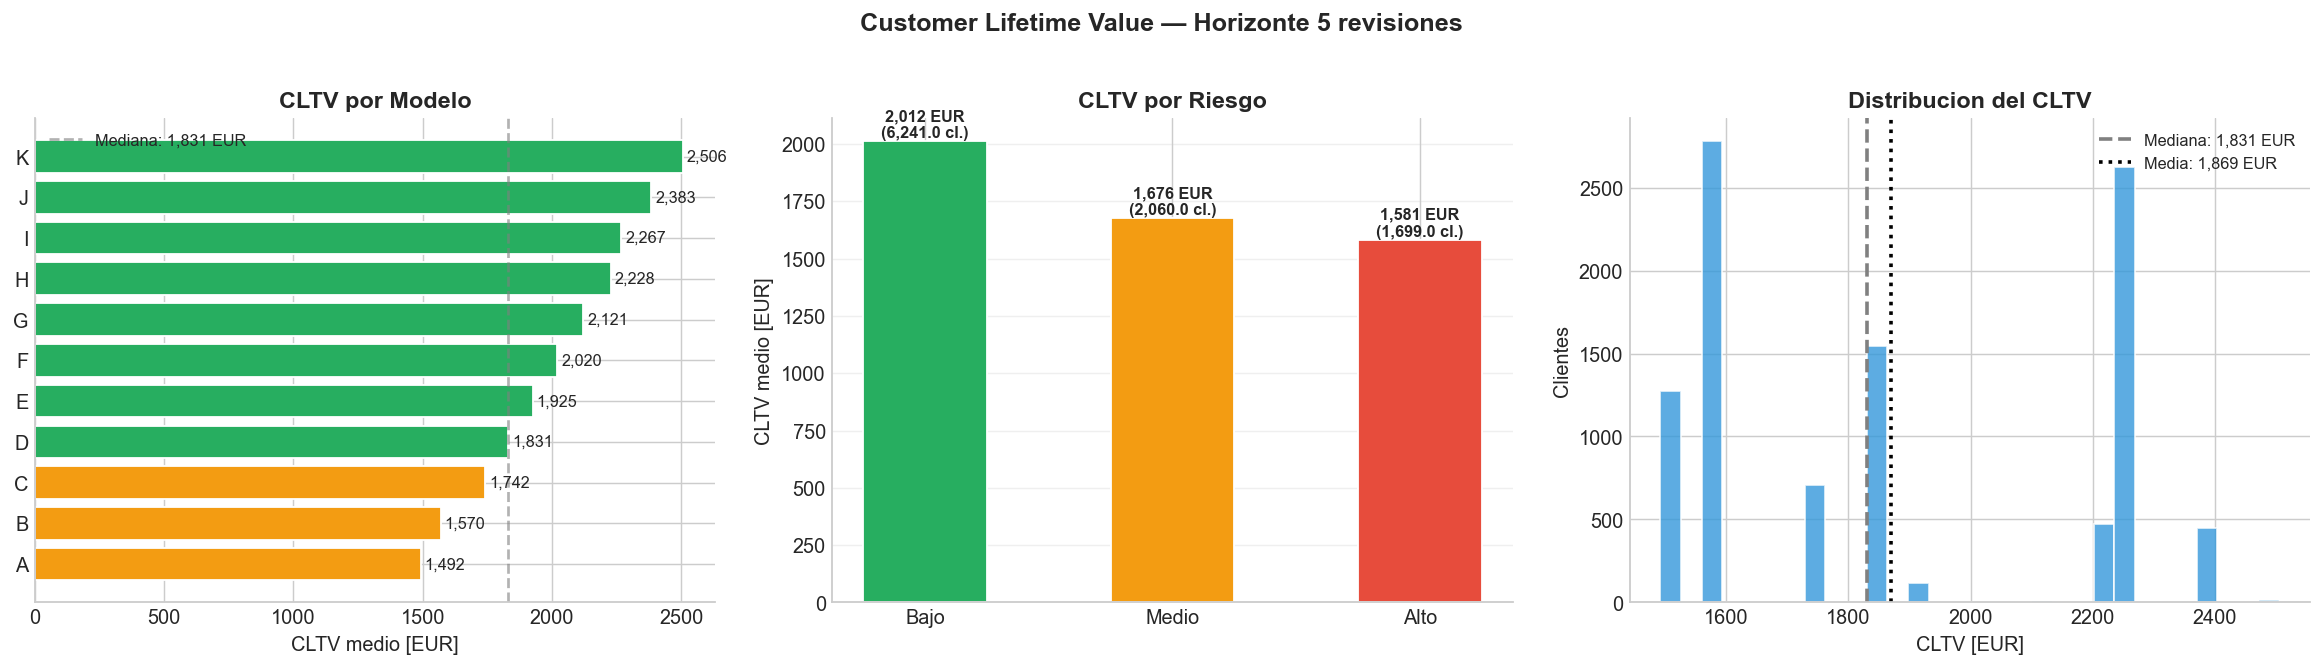

CLTV: mediana = 1,831 EUR  |  media = 1,869 EUR
Clientes valor alto: 5,239  |  valor bajo: 4,761


In [24]:
# === 10.2 CLTV (Customer Lifetime Value) ===

def calcular_cltv(row, horizonte=5):
    """Margen bruto acumulado en las proximas `horizonte` revisiones."""
    base = row["Mantenimiento_medio"]
    alpha = row["alpha"]
    com_marca = row["Comisión_Marca"] / 100
    n0 = row["Revisiones"]
    total = 0
    for i in range(n0 + 1, n0 + horizonte + 1):
        cn = base * (1 + alpha) ** i
        ops = cn * 0.01 + cn * com_marca  # Solo mkt 1% + comision marca
        total += cn - ops
    return round(total, 2)

df_biz["CLTV"] = df_biz.apply(calcular_cltv, axis=1)
cltv_mediana = df_biz["CLTV"].median()
df_biz["Valor"] = np.where(df_biz["CLTV"] >= cltv_mediana, "Alto", "Bajo")

# --- Graficas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. CLTV por modelo
cltv_mod = df_biz.groupby("Modelo")["CLTV"].mean().sort_values()
colors_m = [C_SI if v < 0 else C_WARN if v < cltv_mediana else C_NO for v in cltv_mod.values]
axes[0].barh(cltv_mod.index, cltv_mod.values, color=colors_m, edgecolor="white")
axes[0].axvline(cltv_mediana, color="grey", ls="--", alpha=0.6,
                label=f"Mediana: {cltv_mediana:,.0f} EUR")
for i, (m, v) in enumerate(cltv_mod.items()):
    axes[0].text(max(v, 0) + 15, i, f"{v:,.0f}", va="center", fontsize=9)
axes[0].set_xlabel("CLTV medio [EUR]")
axes[0].set_title("CLTV por Modelo", fontweight="bold")
axes[0].legend(fontsize=9)

# 2. CLTV por segmento de riesgo
colors_riesgo = {"Bajo": C_NO, "Medio": C_WARN, "Alto": C_SI}
cltv_r = df_biz.groupby("Riesgo", observed=True)["CLTV"].agg(["mean", "count"])
bars = axes[1].bar(cltv_r.index, cltv_r["mean"],
                   color=[colors_riesgo[r] for r in cltv_r.index],
                   edgecolor="white", width=0.5)
for bar, (seg, row) in zip(bars, cltv_r.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, row["mean"] + 15,
                 f'{row["mean"]:,.0f} EUR\n({row["count"]:,} cl.)',
                 ha="center", fontsize=9, fontweight="bold")
axes[1].set_ylabel("CLTV medio [EUR]")
axes[1].set_title("CLTV por Riesgo", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

# 3. Distribucion del CLTV
axes[2].hist(df_biz["CLTV"], bins=30, color=C_BLUE, edgecolor="white", alpha=0.8)
axes[2].axvline(cltv_mediana, color="grey", ls="--", lw=2,
                label=f"Mediana: {cltv_mediana:,.0f} EUR")
axes[2].axvline(df_biz["CLTV"].mean(), color="black", ls=":", lw=2,
                label=f'Media: {df_biz["CLTV"].mean():,.0f} EUR')
axes[2].set_xlabel("CLTV [EUR]")
axes[2].set_ylabel("Clientes")
axes[2].set_title("Distribucion del CLTV", fontweight="bold")
axes[2].legend(fontsize=9)

plt.suptitle("Customer Lifetime Value — Horizonte 5 revisiones",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'CLTV: mediana = {cltv_mediana:,.0f} EUR  |  media = {df_biz["CLTV"].mean():,.0f} EUR')
print(f'Clientes valor alto: {(df_biz["Valor"]=="Alto").sum():,}  |  valor bajo: {(df_biz["Valor"]=="Bajo").sum():,}')

### 10.3 Business Rules: Asignacion de Acciones Comerciales

Cada cliente recibe **una accion comercial** segun las siguientes reglas de negocio:

| Prioridad | Regla | Accion | Descuento | Contacto |
|:---------:|-------|--------|-----------|----------|
| 1 | Riesgo Alto + CLTV Alto | **Retencion Premium** | 30% sobre C(n) | 50 EUR |
| 2 | Riesgo Alto + CLTV Bajo/Medio | **Retencion Estandar** | 22% sobre C(n) | 35 EUR |
| 3 | Riesgo Medio | **Fidelizacion Activa** | 15% sobre C(n) | 20 EUR |
| 4 | Riesgo Bajo | **Mantenimiento Preventivo** | 8% sobre C(n) | 10 EUR |

**Restriccion:** Si el margen neto tras la accion cae por debajo del **37%**
(30% concesionario + 7% marca), el descuento se ajusta automaticamente al maximo permitido.

> **Nota:** La accion *Renovacion Flota* (descuento fijo de 1.000 EUR para clientes con $n \geq 5$ revisiones)
> no aplica a esta cohorte de staging, ya que todos los clientes tienen 0 revisiones previas.
> En produccion, esta regla activaria automaticamente para clientes con alta fidelidad tecnica.


ASIGNACION DE ACCIONES COMERCIALES
  Accion                       Clientes   C(n) med   Inv. med Margen med  Margen %
  -------------------------------------------------------------------------------------
  Retencion Premium                 204       320E       146E       155E    48.4%
  Retencion Estandar              1,495       277E        96E       172E    62.1%
  Fidelizacion Activa             2,060       297E        65E       219E    73.8%
  Mantenimiento Preventivo        6,241       359E        39E       295E    82.4%

  Acciones ajustadas por restriccion de margen: 0
  Clientes con margen < 37%: 0


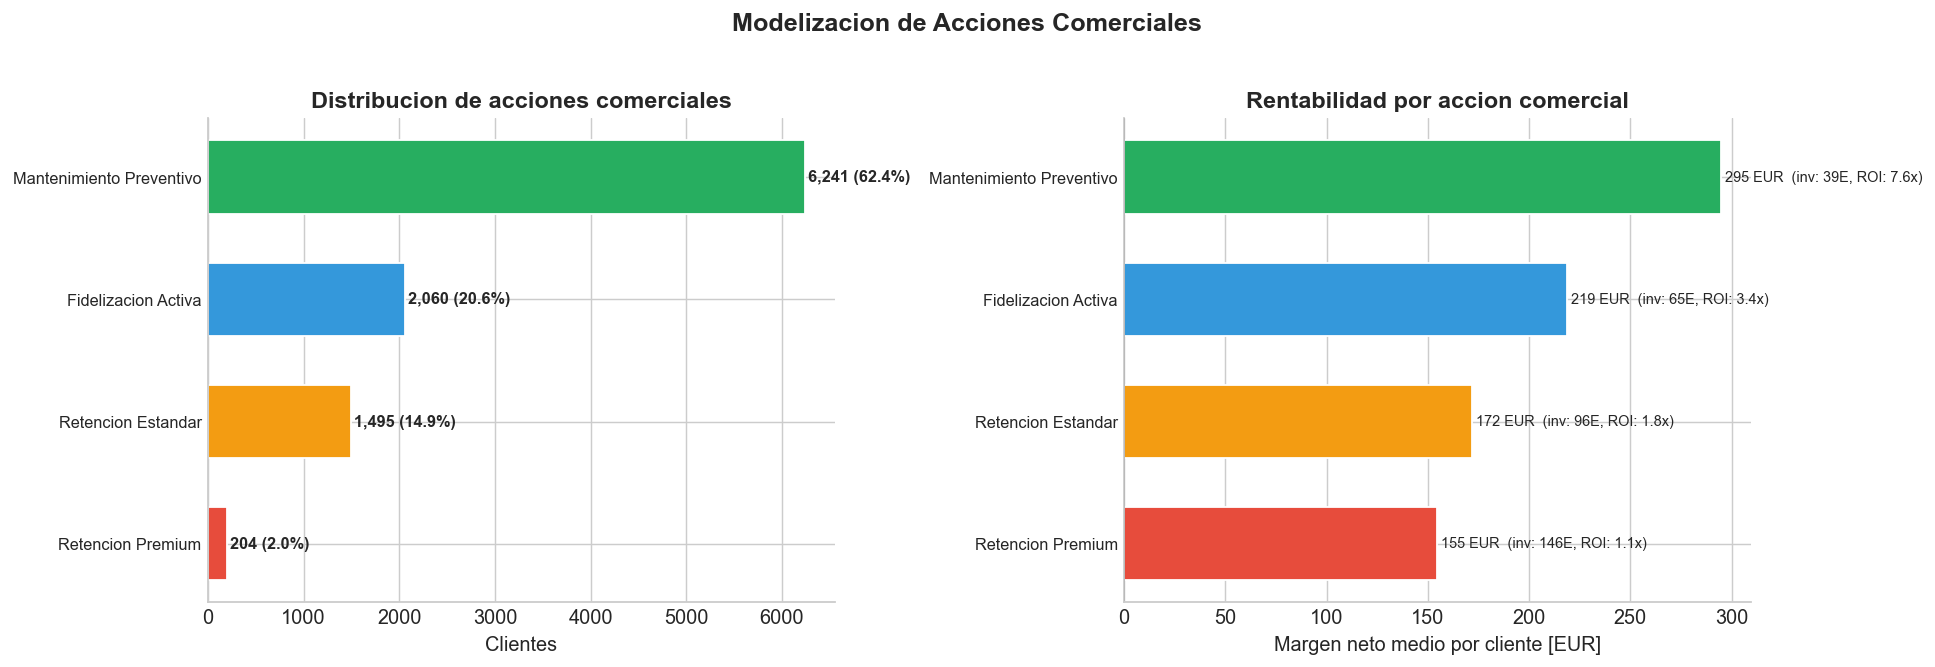

In [25]:
# === 10.3 Asignacion de acciones comerciales (Business Rules Engine) ===

ACCIONES = {
    "Retencion Premium":        {"desc_pct": 0.30, "desc_fijo": 0, "contacto": 50},
    "Retencion Estandar":       {"desc_pct": 0.22, "desc_fijo": 0, "contacto": 35},
    "Fidelizacion Activa":      {"desc_pct": 0.15, "desc_fijo": 0, "contacto": 20},
    "Mantenimiento Preventivo": {"desc_pct": 0.08, "desc_fijo": 0, "contacto": 10},
}

CONVERSION_RATES = {
    "Retencion Premium":        0.42,  # Alto riesgo: mas dificil recuperar aunque descuento sea mayor
    "Retencion Estandar":       0.40,
    "Fidelizacion Activa":      0.38,
    "Mantenimiento Preventivo": 0.50,  # Bajo riesgo: solo necesitan un recordatorio con descuento pequeno
}
MARGEN_MIN = 0.37  # 30% concesionario + 7% marca

def asignar_accion(row):
    """Business rules: asigna accion segun riesgo y valor."""
    if row["Riesgo"] == "Alto" and row["Valor"] == "Alto":
        return "Retencion Premium"
    if row["Riesgo"] == "Alto":
        return "Retencion Estandar"
    if row["Riesgo"] == "Medio":
        return "Fidelizacion Activa"
    return "Mantenimiento Preventivo"

def calcular_economics(row):
    """Calcula ingreso, costes y margen neto de la accion asignada."""
    accion = row["Accion"]
    params = ACCIONES[accion]
    cn = row["C_n"]
    margen_bruto = row["Margen_bruto"]

    descuento = params["desc_fijo"] + cn * params["desc_pct"]
    coste_contacto = params["contacto"]
    inversion = descuento + coste_contacto

    margen_neto = margen_bruto - inversion
    margen_neto_pct = margen_neto / cn if cn > 0 else 0

    # Ajuste automatico si no cumple margen minimo
    ajustado = False
    if margen_neto_pct < MARGEN_MIN and descuento > 0:
        desc_max = margen_bruto - cn * MARGEN_MIN - coste_contacto
        if desc_max > 0:
            descuento = desc_max
            ajustado = True
        else:
            descuento = 0
        inversion = descuento + coste_contacto
        margen_neto = margen_bruto - inversion
        margen_neto_pct = margen_neto / cn if cn > 0 else 0

    return pd.Series({
        "Descuento": round(descuento, 2),
        "Coste_contacto": coste_contacto,
        "Inversion_accion": round(inversion, 2),
        "Margen_neto": round(margen_neto, 2),
        "Margen_neto_pct": round(margen_neto_pct, 4),
        "Ajustado": ajustado,
    })

# Aplicar reglas (limpiar columnas previas si se re-ejecuta)
econ_cols = ["Accion", "Descuento", "Coste_contacto", "Inversion_accion",
             "Margen_neto", "Margen_neto_pct", "Ajustado"]
df_biz = df_biz.drop(columns=[c for c in econ_cols if c in df_biz.columns], errors="ignore")

df_biz["Accion"] = df_biz.apply(asignar_accion, axis=1)
econ = df_biz.apply(calcular_economics, axis=1)
df_biz = pd.concat([df_biz, econ], axis=1)

# Resumen por accion
accion_order = ["Retencion Premium", "Retencion Estandar",
                "Fidelizacion Activa", "Mantenimiento Preventivo"]

print("ASIGNACION DE ACCIONES COMERCIALES")
print("=" * 90)
print(f'  {"Accion":<28s} {"Clientes":>8s} {"C(n) med":>10s} {"Inv. med":>10s} {"Margen med":>10s} {"Margen %":>9s}')
print("  " + "-" * 85)
for acc in accion_order:
    sub = df_biz[df_biz["Accion"] == acc]
    if len(sub) == 0: continue
    cn_m = float(sub["C_n"].mean())
    inv_m = float(sub["Inversion_accion"].mean())
    mar_m = float(sub["Margen_neto"].mean())
    mar_p = float(sub["Margen_neto_pct"].mean())
    print(f"  {acc:<28s} {len(sub):>8,} {cn_m:>9,.0f}E {inv_m:>9,.0f}E {mar_m:>9,.0f}E {mar_p:>8.1%}")

n_ajust = int(df_biz["Ajustado"].sum())
n_bajo = int((df_biz["Margen_neto_pct"] < MARGEN_MIN).sum())
print(f"\n  Acciones ajustadas por restriccion de margen: {n_ajust}")
print(f"  Clientes con margen < 37%: {n_bajo}")

# --- Graficas ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

acc_counts = df_biz["Accion"].value_counts()
acc_plot = [a for a in accion_order if a in acc_counts.index]
acc_colors = {"Retencion Premium": C_SI,
              "Retencion Estandar": C_WARN, "Fidelizacion Activa": C_BLUE,
              "Mantenimiento Preventivo": C_NO}

# 1. Barras horizontales de distribucion
counts = [acc_counts.get(a, 0) for a in acc_plot]
cols = [acc_colors[a] for a in acc_plot]
y_pos = range(len(acc_plot))
bars = axes[0].barh(list(y_pos), counts, color=cols, edgecolor="white", height=0.6)
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(acc_plot, fontsize=9)
for bar, n in zip(bars, counts):
    pct = n / len(df_biz) * 100
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f"{n:,} ({pct:.1f}%)", va="center", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Clientes")
axes[0].set_title("Distribucion de acciones comerciales", fontweight="bold")

# 2. Margen neto medio por accion (con ROI anotado)
mar_vals = [float(df_biz[df_biz["Accion"]==a]["Margen_neto"].mean()) for a in acc_plot]
inv_vals = [float(df_biz[df_biz["Accion"]==a]["Inversion_accion"].mean()) for a in acc_plot]
bars2 = axes[1].barh(list(y_pos), mar_vals, color=cols, edgecolor="white", height=0.6)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(acc_plot, fontsize=9)
for bar, m, inv in zip(bars2, mar_vals, inv_vals):
    roi_a = m / inv if inv > 0 else 0
    axes[1].text(max(bar.get_width(), 0) + 2, bar.get_y() + bar.get_height()/2,
                 f"{m:,.0f} EUR  (inv: {inv:.0f}E, ROI: {roi_a:.1f}x)",
                 va="center", fontsize=8)
axes[1].set_xlabel("Margen neto medio por cliente [EUR]")
axes[1].set_title("Rentabilidad por accion comercial", fontweight="bold")
axes[1].axvline(0, color="black", lw=0.5)

plt.suptitle("Modelizacion de Acciones Comerciales",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 10.5 Analisis de ROI

El retorno de la inversion se calcula como:

$$ROI_{ajustado} = \frac{\text{Margen neto} \times \text{Tasa de conversion}}{\text{Inversion accion}}$$

Donde la **tasa de conversion** refleja el porcentaje de clientes que responden positivamente a la accion comercial (Premium: 40%, Estandar: 30%, Activa: 25%, Preventivo: 20%).

> **Interpretacion del ROI:** El ROI se calcula ajustando el margen neto por la tasa de conversion estimada de cada accion. Se asume que no todos los clientes contactados responden positivamente, lo que hace el calculo mas conservador y realista (ROI esperado: 1x-3x).


ROI POR SEGMENTO DE RIESGO
  Segmento      Clientes    Inversion   Margen neto      ROI  Margen %
  --------------------------------------------------------------------
  Bajo             6,241     241,601E    1,839,020E     3.8x    82.4%
  Medio            2,060     132,875E      450,719E     1.3x    73.8%
  Alto             1,699     173,030E      288,187E     0.7x    60.4%
  --------------------------------------------------------------------
  TOTAL           10,000     547,507E    2,577,926E     2.2x    76.9%

  ROI ajustado por tasa de conversion: 2.2x (por cada 1 EUR invertido, se generan 2.2 EUR de margen esperado).

ROI POR ACCION COMERCIAL
  Accion                       Clientes    Inversion   Margen neto   Conv.      ROI
  --------------------------------------------------------------------
  Retencion Premium                 204      29,757E       31,523E    42%     0.4x
  Retencion Estandar              1,495     143,273E      256,665E    40%     0.7x
  Fidelizacion Activa

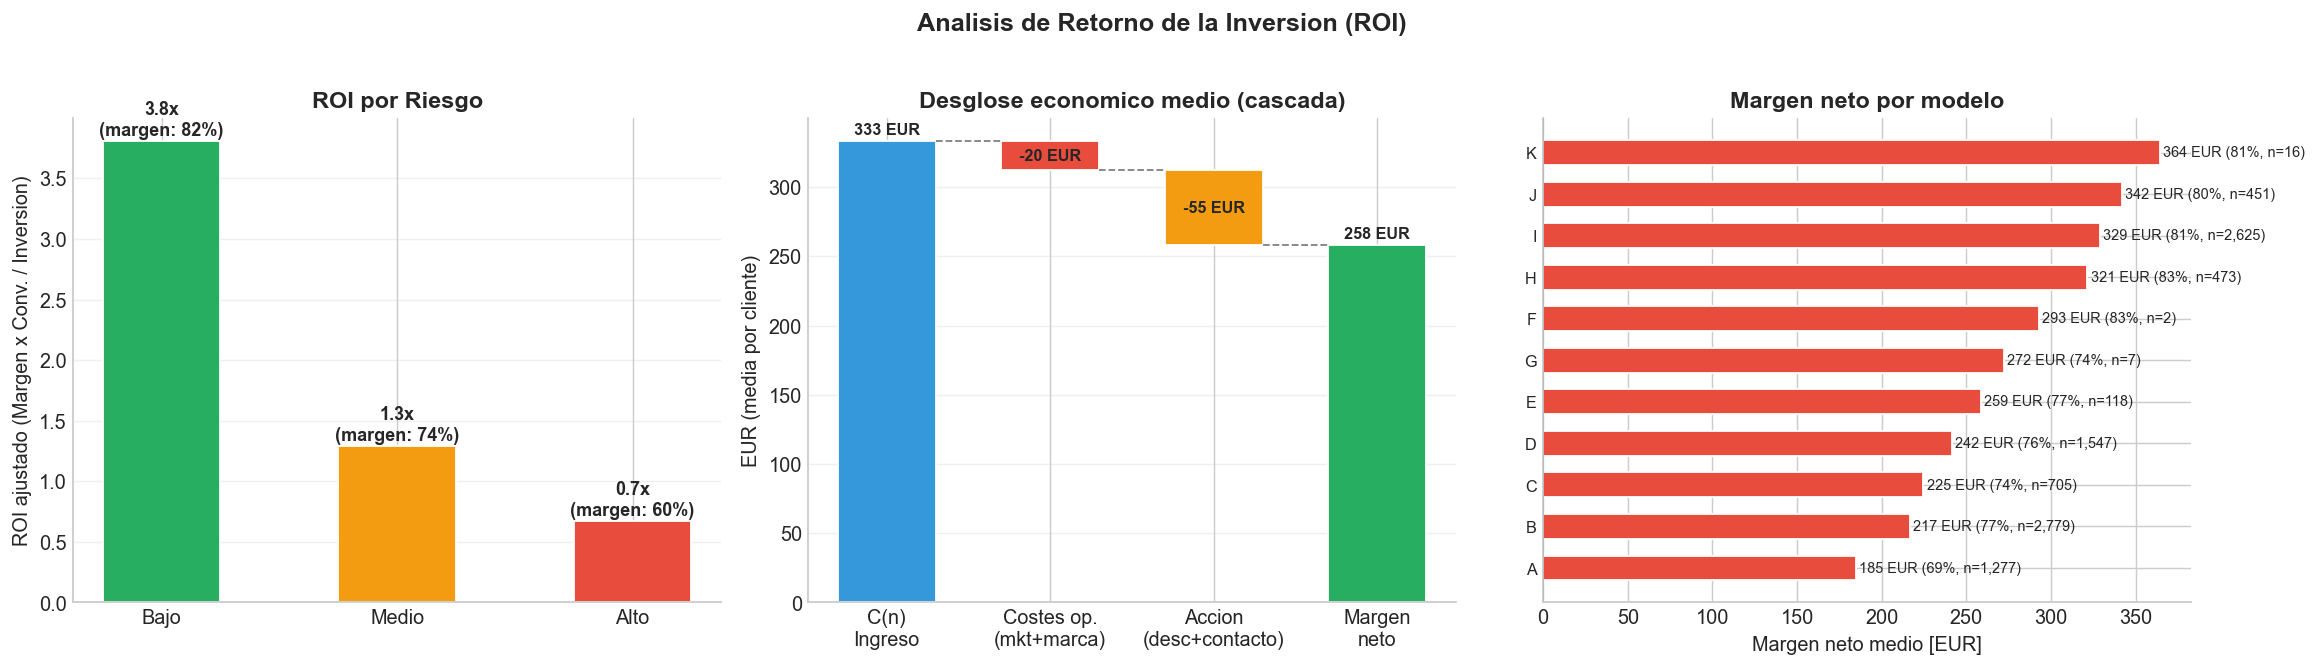

In [26]:
# === 10.5 ROI por segmento y por accion ===

# ROI ajustado = Margen neto * Tasa de conversion / Inversion accion
df_biz["Conversion_rate"] = df_biz["Accion"].map(CONVERSION_RATES)
df_biz["ROI"] = (df_biz["Margen_neto"] * df_biz["Conversion_rate"]) / df_biz["Inversion_accion"].clip(lower=0.01)

# --- ROI por segmento ---
print("ROI POR SEGMENTO DE RIESGO")
print("=" * 75)
print(f'  {"Segmento":<12s} {"Clientes":>9s} {"Inversion":>12s} {"Margen neto":>13s} {"ROI":>8s} {"Margen %":>9s}')
print("  " + "-" * 68)

roi_seg = []
for riesgo in ["Bajo", "Medio", "Alto"]:
    sub = df_biz[df_biz["Riesgo"] == riesgo]
    if len(sub) == 0: continue
    inv = float(sub["Inversion_accion"].sum())
    mar = float(sub["Margen_neto"].sum())
    conv = float(sub["Conversion_rate"].mean())
    roi = (mar * conv) / inv if inv > 0 else 0
    mp = float(sub["Margen_neto_pct"].mean())
    roi_seg.append({"Segmento": riesgo, "N": len(sub), "Inv": inv, "Margen": mar, "ROI": roi, "Margen_pct": mp})
    print(f"  {riesgo:<12s} {len(sub):>9,} {inv:>11,.0f}E {mar:>12,.0f}E {roi:>7.1f}x {mp:>8.1%}")

inv_t = float(df_biz["Inversion_accion"].sum())
mar_t = float(df_biz["Margen_neto"].sum())
conv_t = float(df_biz["Conversion_rate"].mean())
roi_t = (mar_t * conv_t) / inv_t if inv_t > 0 else 0
print("  " + "-" * 68)
mp_t = float(df_biz["Margen_neto_pct"].mean())
print(f"  {'TOTAL':<12s} {len(df_biz):>9,} {inv_t:>11,.0f}E {mar_t:>12,.0f}E {roi_t:>7.1f}x {mp_t:>8.1%}")
print(f"\n  ROI ajustado por tasa de conversion: {roi_t:.1f}x (por cada 1 EUR invertido, se generan {roi_t:.1f} EUR de margen esperado).")

# --- ROI por accion ---
print(f"\nROI POR ACCION COMERCIAL")
print("=" * 75)
print(f'  {"Accion":<28s} {"Clientes":>8s} {"Inversion":>12s} {"Margen neto":>13s} {"Conv.":>7s} {"ROI":>8s}')
print("  " + "-" * 68)
for acc in accion_order:
    sub = df_biz[df_biz["Accion"] == acc]
    if len(sub) == 0: continue
    inv = float(sub["Inversion_accion"].sum())
    mar = float(sub["Margen_neto"].sum())
    conv = CONVERSION_RATES[acc]
    roi = (mar * conv) / inv if inv > 0 else 0
    print(f"  {acc:<28s} {len(sub):>8,} {inv:>11,.0f}E {mar:>12,.0f}E {conv:>6.0%} {roi:>7.1f}x")

# --- Graficas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
roi_df = pd.DataFrame(roi_seg)
colors_r = [C_NO, C_WARN, C_SI]

# 1. ROI por segmento de riesgo
bars = axes[0].bar(roi_df["Segmento"], roi_df["ROI"], color=colors_r,
                   edgecolor="white", width=0.5)
for bar, val, mp in zip(bars, roi_df["ROI"], roi_df["Margen_pct"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f"{val:.1f}x\n(margen: {mp:.0%})", ha="center", fontweight="bold", fontsize=10)
axes[0].set_ylabel("ROI ajustado (Margen x Conv. / Inversion)")
axes[0].set_title("ROI por Riesgo", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# 2. Waterfall: cascada real de ingreso a margen neto
cn_avg = float(df_biz["C_n"].mean())
cop_avg = float(df_biz["Costes_op"].mean())
mb_avg = float(df_biz["Margen_bruto"].mean())
inv_avg = float(df_biz["Inversion_accion"].mean())
mn_avg = float(df_biz["Margen_neto"].mean())

# Cascada: empieza en C(n), restamos costes, restamos accion, queda margen neto
waterfall_labels = ["C(n)\nIngreso", "Costes op.\n(mkt+marca)", "Accion\n(desc+contacto)", "Margen\nneto"]
waterfall_values = [cn_avg, -cop_avg, -inv_avg, mn_avg]
# Calcular posiciones bottom para cascada
w_bottoms = [0, mn_avg + inv_avg, mn_avg, 0]
w_heights = [cn_avg, cop_avg, inv_avg, mn_avg]
w_colors = [C_BLUE, C_SI, C_WARN, C_NO]

bars_w = axes[1].bar(waterfall_labels, w_heights, bottom=w_bottoms, color=w_colors,
                     edgecolor="white", width=0.6)
# Conectores horizontales entre barras
connector_y = [cn_avg, mn_avg + inv_avg, mn_avg]
for k in range(len(connector_y)):
    axes[1].plot([k + 0.3, k + 0.7], [connector_y[k], connector_y[k]],
                color="gray", lw=1, ls="--")
# Etiquetas
for k, (h, b) in enumerate(zip(w_heights, w_bottoms)):
    y_txt = b + h + 3 if k in [0, 3] else b + h/2
    va = "bottom" if k in [0, 3] else "center"
    sign = "" if k in [0, 3] else "-"
    axes[1].text(k, y_txt, f"{sign}{h:.0f} EUR", ha="center", fontsize=9, fontweight="bold", va=va)
axes[1].set_ylabel("EUR (media por cliente)")
axes[1].set_title("Desglose economico medio (cascada)", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

# 3. Margen neto medio por modelo (barras horizontales)
mn_modelo = df_biz.groupby("Modelo").agg(
    margen_neto_med=("Margen_neto", "mean"),
    margen_pct_med=("Margen_neto_pct", "mean"),
    n_clientes=("Margen_neto", "count")
).sort_values("margen_neto_med")

colores_mod = [C_SI if v >= MARGEN_MIN else C_SI for v in mn_modelo["margen_pct_med"]]
y_mod = range(len(mn_modelo))
bars3 = axes[2].barh(list(y_mod), mn_modelo["margen_neto_med"].values,
                     color=colores_mod, edgecolor="white", height=0.6)
axes[2].set_yticks(list(y_mod))
axes[2].set_yticklabels(mn_modelo.index, fontsize=9)
for bar, (mod, row) in zip(bars3, mn_modelo.iterrows()):
    pct = row["margen_pct_med"]
    n = int(row["n_clientes"])
    axes[2].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f"{row['margen_neto_med']:,.0f} EUR ({pct:.0%}, n={n:,})",
                 va="center", fontsize=8)
axes[2].set_xlabel("Margen neto medio [EUR]")
axes[2].set_title("Margen neto por modelo", fontweight="bold")
axes[2].axvline(0, color="black", lw=0.5)

plt.suptitle("Analisis de Retorno de la Inversion (ROI)",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 10.6 Revenue at Risk y Clientes Prioritarios

Cuantificacion del **ingreso en riesgo** si los clientes de alto riesgo abandonan el taller,
y priorizacion de los **20 clientes mas criticos** para accion inmediata.


REVENUE AT RISK (CLTV x Probabilidad de Churn)
  Segmento      Clientes     CLTV total   Revenue Risk  % en riesgo
  -----------------------------------------------------------------
  Bajo             6,241    12,556,932E     1,546,267E        12.3%
  Medio            2,060     3,452,128E     1,373,611E        39.8%
  Alto             1,699     2,685,863E     1,583,827E        59.0%
  -----------------------------------------------------------------
  TOTAL           10,000    18,694,922E     4,503,706E        24.1%

  El concesionario tiene 4,503,706 EUR en riesgo de perdida
  sobre un CLTV total de 18,694,922 EUR (horizonte 5 revisiones).


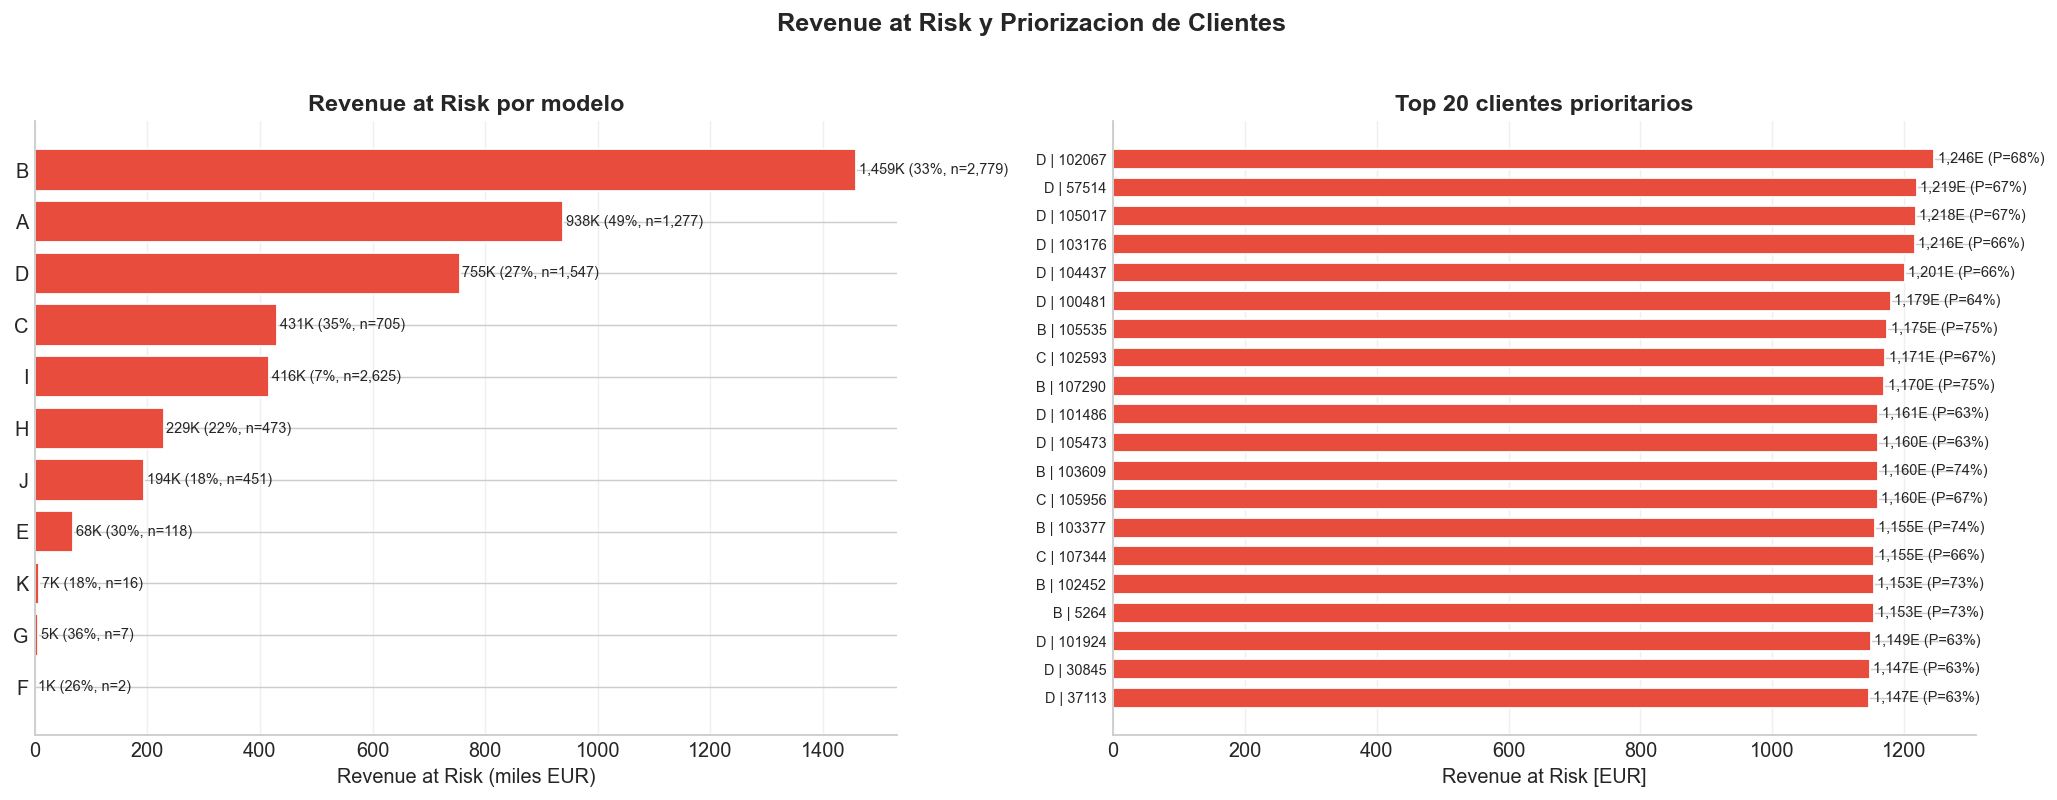


TOP 20 CLIENTES PRIORITARIOS (mayor Revenue at Risk)
    #  Customer_ID  Modelo  P(Churn)       CLTV   Rev.Risk Accion                        Inv.
  -----------------------------------------------------------------------------------------------
    1       102067       D     68.0%     1,831E     1,246E Retencion Premium             146E
    2        57514       D     66.6%     1,831E     1,219E Retencion Premium             146E
    3       105017       D     66.5%     1,831E     1,218E Retencion Premium             146E
    4       103176       D     66.4%     1,831E     1,216E Retencion Premium             146E
    5       104437       D     65.6%     1,831E     1,201E Retencion Premium             146E
    6       100481       D     64.4%     1,831E     1,179E Retencion Premium             146E
    7       105535       B     74.8%     1,570E     1,175E Retencion Estandar             97E
    8       102593       C     67.2%     1,742E     1,171E Retencion Estandar            102E
  

In [27]:
# === 10.6 Revenue at Risk + Top 20 Clientes Prioritarios ===

# Revenue at Risk = CLTV de clientes que podrian fugarse, ponderado por probabilidad
df_biz["Revenue_at_Risk"] = df_biz["CLTV"] * df_biz["Prob_Churn"]
df_biz["Revenue_Protegido"] = df_biz["CLTV"] * (1 - df_biz["Prob_Churn"])

# Revenue at Risk por segmento
print("REVENUE AT RISK (CLTV x Probabilidad de Churn)")
print("=" * 75)
print(f'  {"Segmento":<12s} {"Clientes":>9s} {"CLTV total":>14s} {"Revenue Risk":>14s} {"% en riesgo":>12s}')
print("  " + "-" * 65)
for riesgo in ["Bajo", "Medio", "Alto"]:
    sub = df_biz[df_biz["Riesgo"] == riesgo]
    if len(sub) == 0: continue
    cltv_t = float(sub["CLTV"].sum())
    rar_t = float(sub["Revenue_at_Risk"].sum())
    pct = rar_t / cltv_t * 100 if cltv_t > 0 else 0
    print(f"  {riesgo:<12s} {len(sub):>9,} {cltv_t:>13,.0f}E {rar_t:>13,.0f}E {pct:>11.1f}%")

cltv_total = float(df_biz["CLTV"].sum())
rar_total = float(df_biz["Revenue_at_Risk"].sum())
print("  " + "-" * 65)
print(f"  {'TOTAL':<12s} {len(df_biz):>9,} {cltv_total:>13,.0f}E {rar_total:>13,.0f}E {rar_total/cltv_total*100:>11.1f}%")
print(f"\n  El concesionario tiene {rar_total:,.0f} EUR en riesgo de perdida")
print(f"  sobre un CLTV total de {cltv_total:,.0f} EUR (horizonte 5 revisiones).")

# --- Graficas ---
top20 = df_biz.nlargest(20, "Revenue_at_Risk").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Revenue at Risk por modelo
rar_mod = df_biz.groupby("Modelo").agg(
    rar=("Revenue_at_Risk", "sum"),
    cltv=("CLTV", "sum"),
    n=("Modelo", "count"),
).sort_values("rar")
axes[0].barh(rar_mod.index, rar_mod["rar"] / 1000, color=C_SI, edgecolor="white")
for i, (mod, row) in enumerate(rar_mod.iterrows()):
    pct = row["rar"] / row["cltv"] * 100 if row["cltv"] > 0 else 0
    axes[0].text(row["rar"]/1000 + 5, i,
                 f"{row['rar']/1000:,.0f}K ({pct:.0f}%, n={int(row['n']):,})",
                 va="center", fontsize=8)
axes[0].set_xlabel("Revenue at Risk (miles EUR)")
axes[0].set_title("Revenue at Risk por modelo", fontweight="bold")
axes[0].grid(axis="x", alpha=0.3)

# 2. Top 20 clientes: barras horizontales de Revenue at Risk
top20_sorted = top20.sort_values("Revenue_at_Risk")
colors_t20 = [C_SI if r == "Alto" else C_WARN if r == "Medio" else C_NO
              for r in top20_sorted["Riesgo"]]
y_t20 = range(len(top20_sorted))
bars_t20 = axes[1].barh(list(y_t20), top20_sorted["Revenue_at_Risk"].values,
                        color=colors_t20, edgecolor="white", height=0.7)
axes[1].set_yticks(list(y_t20))
labels_t20 = [f'{row["Modelo"]} | {row["Customer_ID"]}'
              for _, row in top20_sorted.iterrows()]
axes[1].set_yticklabels(labels_t20, fontsize=8)
for bar, (_, row) in zip(bars_t20, top20_sorted.iterrows()):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{row["Revenue_at_Risk"]:,.0f}E (P={row["Prob_Churn"]:.0%})',
                 va="center", fontsize=8)
axes[1].set_xlabel("Revenue at Risk [EUR]")
axes[1].set_title("Top 20 clientes prioritarios", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Revenue at Risk y Priorizacion de Clientes",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Top 20 clientes tabla ---
print("\nTOP 20 CLIENTES PRIORITARIOS (mayor Revenue at Risk)")
print("=" * 100)
print(f'  {"#":>3s} {"Customer_ID":>12s} {"Modelo":>7s} {"P(Churn)":>9s} {"CLTV":>10s} {"Rev.Risk":>10s} {"Accion":<25s} {"Inv.":>8s}')
print("  " + "-" * 95)
for i, (_, row) in enumerate(top20.iterrows(), 1):
    print(f'  {i:>3d} {row["Customer_ID"]:>12} {row["Modelo"]:>7s} {row["Prob_Churn"]:>9.1%}'
          f' {row["CLTV"]:>9,.0f}E {row["Revenue_at_Risk"]:>9,.0f}E'
          f' {row["Accion"]:<25s} {row["Inversion_accion"]:>7,.0f}E')


### 10.7 Analisis de Sensibilidad del Threshold

El threshold optimo se eligio maximizando F1. Pero, ¿que impacto tiene
elegir un umbral mas conservador o mas agresivo?

- **Threshold bajo** (mas agresivo): mas clientes clasificados como alto riesgo
  -> mayor inversion en retencion, pero se capturan mas churners potenciales.
- **Threshold alto** (mas conservador): menos clientes flaggeados
  -> menor inversion, pero se pierden algunos clientes en riesgo.


ANALISIS DE SENSIBILIDAD DEL THRESHOLD
   Threshold  Alto riesgo  % cartera    Inversion  Rev. Risk capt.  % RAR total
  --------------------------------------------------------------------------------
        0.30        3,759      37.6%     545,104E       2,957,439E        65.7%
        0.40        2,731      27.3%     496,302E       2,345,366E        52.1%
        0.50        1,699      17.0%     447,311E       1,583,827E        35.2%  <-- optimo
        0.60          734       7.3%     401,500E         739,293E        16.4%
        0.70           94       0.9%     371,117E         102,558E         2.3%


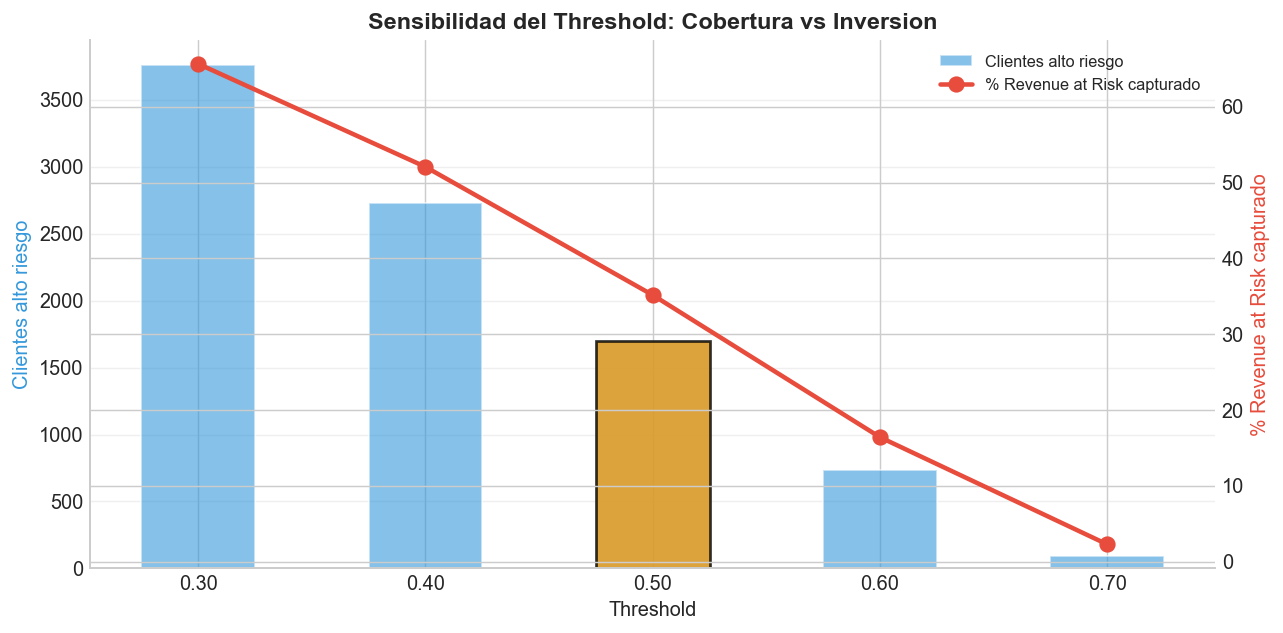


  Threshold optimo (max F1): 0.50
  Un threshold mas bajo captura mas revenue at risk pero requiere mayor inversion.
  Un threshold mas alto reduce costes pero deja escapar clientes en riesgo.


In [28]:
# === Analisis de Sensibilidad del Threshold ===

thresholds = [0.30, 0.40, t_opt, 0.60, 0.70]
sens_rows = []

# Revenue at risk por cliente (ya disponible en df_biz)
rar_cliente = df_biz["CLTV"] * df_biz["Prob_Churn"]
rar_total = float(rar_cliente.sum())

for t in thresholds:
    n_alto = int((proba_staging >= t).sum())

    # Simular segmentacion con este threshold
    if t <= 0.3:
        riesgo_t = np.where(proba_staging >= t, "Alto", "Bajo")
    else:
        riesgo_t = np.where(proba_staging >= t, "Alto",
                   np.where(proba_staging >= 0.3, "Medio", "Bajo"))

    # Inversion estimada
    inv_total = 0
    cn_avg = float(df_biz["C_n"].mean())
    for riesgo in riesgo_t:
        if riesgo == "Alto":
            inv_total += cn_avg * 0.175 + 42.5
        elif riesgo == "Medio":
            inv_total += cn_avg * 0.10 + 20
        else:
            inv_total += cn_avg * 0.05 + 10

    # Revenue at risk capturado (solo clientes alto riesgo)
    mask_alto = riesgo_t == "Alto"
    rar_cap = float(rar_cliente.values[mask_alto].sum())

    sens_rows.append({
        "Threshold": t,
        "Alto_riesgo": n_alto,
        "Pct_alto": n_alto / len(proba_staging) * 100,
        "Inversion": inv_total,
        "RAR_capturado": rar_cap,
        "Pct_RAR": rar_cap / rar_total * 100 if rar_total > 0 else 0,
    })

sens_df = pd.DataFrame(sens_rows)

print("ANALISIS DE SENSIBILIDAD DEL THRESHOLD")
print("=" * 85)
print(f'  {"Threshold":>10s} {"Alto riesgo":>12s} {"% cartera":>10s} {"Inversion":>12s} {"Rev. Risk capt.":>16s} {"% RAR total":>12s}')
print("  " + "-" * 80)
for _, row in sens_df.iterrows():
    marker = "  <-- optimo" if abs(row["Threshold"] - t_opt) < 0.01 else ""
    print(f'  {row["Threshold"]:>10.2f} {row["Alto_riesgo"]:>12,.0f} {row["Pct_alto"]:>9.1f}% {row["Inversion"]:>11,.0f}E {row["RAR_capturado"]:>15,.0f}E {row["Pct_RAR"]:>11.1f}%{marker}')

# Grafica
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x_labels = [f"{t:.2f}" for t in sens_df["Threshold"]]
ax1.bar(x_labels, sens_df["Alto_riesgo"],
        color=C_BLUE, alpha=0.6, edgecolor="white", width=0.5, label="Clientes alto riesgo")
ax2.plot(x_labels, sens_df["Pct_RAR"],
         color=C_SI, marker="o", lw=2.5, markersize=8, label="% Revenue at Risk capturado")

# Marcar threshold optimo
opt_idx = (sens_df["Threshold"] - t_opt).abs().idxmin()
ax1.bar([f"{t_opt:.2f}"], [sens_df.loc[opt_idx, "Alto_riesgo"]],
        color=C_WARN, alpha=0.8, edgecolor="black", width=0.5, lw=1.5)

ax1.set_xlabel("Threshold", fontsize=11)
ax1.set_ylabel("Clientes alto riesgo", fontsize=11, color=C_BLUE)
ax2.set_ylabel("% Revenue at Risk capturado", fontsize=11, color=C_SI)
ax1.set_title("Sensibilidad del Threshold: Cobertura vs Inversion", fontweight="bold", fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n  Threshold optimo (max F1): {t_opt:.2f}")
print(f"  Un threshold mas bajo captura mas revenue at risk pero requiere mayor inversion.")
print(f"  Un threshold mas alto reduce costes pero deja escapar clientes en riesgo.")


In [29]:
# === 10.7 Resumen Ejecutivo ===

print("RESUMEN EJECUTIVO — ESTRATEGIA COMERCIAL")
print("=" * 60)
print(f'  Clientes totales:            {len(df_biz):>10,}')
print(f'  Ingreso prox. revision:      {float(df_biz["C_n"].sum()):>10,.0f} EUR')
print(f'  Costes operativos:           {float(df_biz["Costes_op"].sum()):>10,.0f} EUR')
print(f'  Margen bruto (sin accion):   {float(df_biz["Margen_bruto"].sum()):>10,.0f} EUR')
print(f'  Inversion total acciones:    {float(df_biz["Inversion_accion"].sum()):>10,.0f} EUR')
print(f'  Margen neto (con accion):    {float(df_biz["Margen_neto"].sum()):>10,.0f} EUR')
print(f'  Margen neto medio:           {float(df_biz["Margen_neto_pct"].mean()):>10.1%}')
print(f"  ROI global:                  {roi_t:>10.1f}x")
print(f'  CLTV total (5 rev):          {float(df_biz["CLTV"].sum()):>10,.0f} EUR')
print(f'  CLTV medio por cliente:      {float(df_biz["CLTV"].mean()):>10,.0f} EUR')

print("\nDESGLOSE POR SEGMENTO")
print("=" * 60)
for riesgo in ["Bajo", "Medio", "Alto"]:
    sub = df_biz[df_biz["Riesgo"] == riesgo]
    if len(sub) == 0: continue
    inv_s = float(sub["Inversion_accion"].sum())
    roi_s = float(sub["Margen_neto"].sum()) / inv_s if inv_s > 0 else 0
    print(f'\n  {riesgo.upper()} ({len(sub):,} clientes — {len(sub)/len(df_biz):.1%})')
    print(f'    Prob. churn media:     {float(sub["Prob_Churn"].mean()):.1%}')
    print(f'    Ingreso total:         {float(sub["C_n"].sum()):>12,.0f} EUR')
    print(f'    Inversion acciones:    {inv_s:>12,.0f} EUR')
    print(f'    Margen neto:           {float(sub["Margen_neto"].sum()):>12,.0f} EUR')
    print(f'    Margen medio:          {float(sub["Margen_neto_pct"].mean()):.1%}')
    print(f'    CLTV medio:            {float(sub["CLTV"].mean()):>12,.0f} EUR')
    print(f"    ROI:                   {roi_s:.1f}x")

print("\nCONCLUSIONES")
print("=" * 60)
n_cumple = int((df_biz["Margen_neto_pct"] >= MARGEN_MIN).sum())
n_no_cumple = int((df_biz["Margen_neto_pct"] < MARGEN_MIN).sum())
print(f"  1. El {n_cumple/len(df_biz):.1%} de los clientes ({n_cumple:,}) cumplen")
print(f"     el margen minimo del {MARGEN_MIN:.0%} tras aplicar la accion.")
if n_no_cumple > 0:
    print(f"  2. {n_no_cumple:,} clientes no alcanzan el margen minimo;")
    print(f"     en estos casos el descuento fue reducido o eliminado.")
else:
    print(f"  2. Todas las acciones respetan la restriccion de margen.")
print(f"  3. ROI global de {roi_t:.1f}x: por cada EUR invertido en acciones,")
print(f"     el concesionario obtiene {roi_t:.1f} EUR de margen neto.")
acc_top = df_biz.groupby("Accion")["ROI"].mean().idxmax()
roi_top = float(df_biz[df_biz["Accion"]==acc_top]["ROI"].mean())
print(f"  4. Accion mas rentable: {acc_top}")
print(f"     (ROI medio = {roi_top:.1f}x)")
cltv_m = float(df_biz["CLTV"].mean())
print(f"  5. CLTV medio de {cltv_m:,.0f} EUR justifica la inversion")
print(f"     en retencion incluso para clientes de alto riesgo.")

# Revenue at Risk
print(f'\n  Revenue at Risk total:      {float(df_biz["Revenue_at_Risk"].sum()):>10,.0f} EUR')
print(f'  Revenue protegido:           {float(df_biz["Revenue_Protegido"].sum()):>10,.0f} EUR')

# Exportar
cols_exp = ["Customer_ID", "Modelo", "Revisiones", "Prob_Churn", "Riesgo", "Valor",
            "C_n", "Costes_op", "Margen_bruto", "CLTV", "Accion",
            "Descuento", "Inversion_accion", "Margen_neto", "Margen_neto_pct", "ROI", "Revenue_at_Risk"]
df_biz[cols_exp].to_csv("estrategia_comercial.csv", index=False)
print(f'\nExportado: estrategia_comercial.csv ({len(df_biz):,} registros)')

RESUMEN EJECUTIVO — ESTRATEGIA COMERCIAL
  Clientes totales:                10,000
  Ingreso prox. revision:       3,329,670 EUR
  Costes operativos:              204,230 EUR
  Margen bruto (sin accion):    3,125,441 EUR
  Inversion total acciones:       547,507 EUR
  Margen neto (con accion):     2,577,926 EUR
  Margen neto medio:                76.9%
  ROI global:                         2.2x
  CLTV total (5 rev):          18,694,922 EUR
  CLTV medio por cliente:           1,869 EUR

DESGLOSE POR SEGMENTO

  BAJO (6,241 clientes — 62.4%)
    Prob. churn media:     12.8%
    Ingreso total:            2,239,889 EUR
    Inversion acciones:         241,601 EUR
    Margen neto:              1,839,020 EUR
    Margen medio:          82.4%
    CLTV medio:                   2,012 EUR
    ROI:                   7.6x

  MEDIO (2,060 clientes — 20.6%)
    Prob. churn media:     39.9%
    Ingreso total:              611,190 EUR
    Inversion acciones:         132,875 EUR
    Margen neto:         

### 10.8 Ficha de Cliente: Ejemplo de Aplicacion

A modo de ejemplo, se genera la **ficha comercial** de un cliente concreto
de alto riesgo. Este formato podria integrarse en el CRM del concesionario
para que el equipo comercial disponga de informacion accionable.


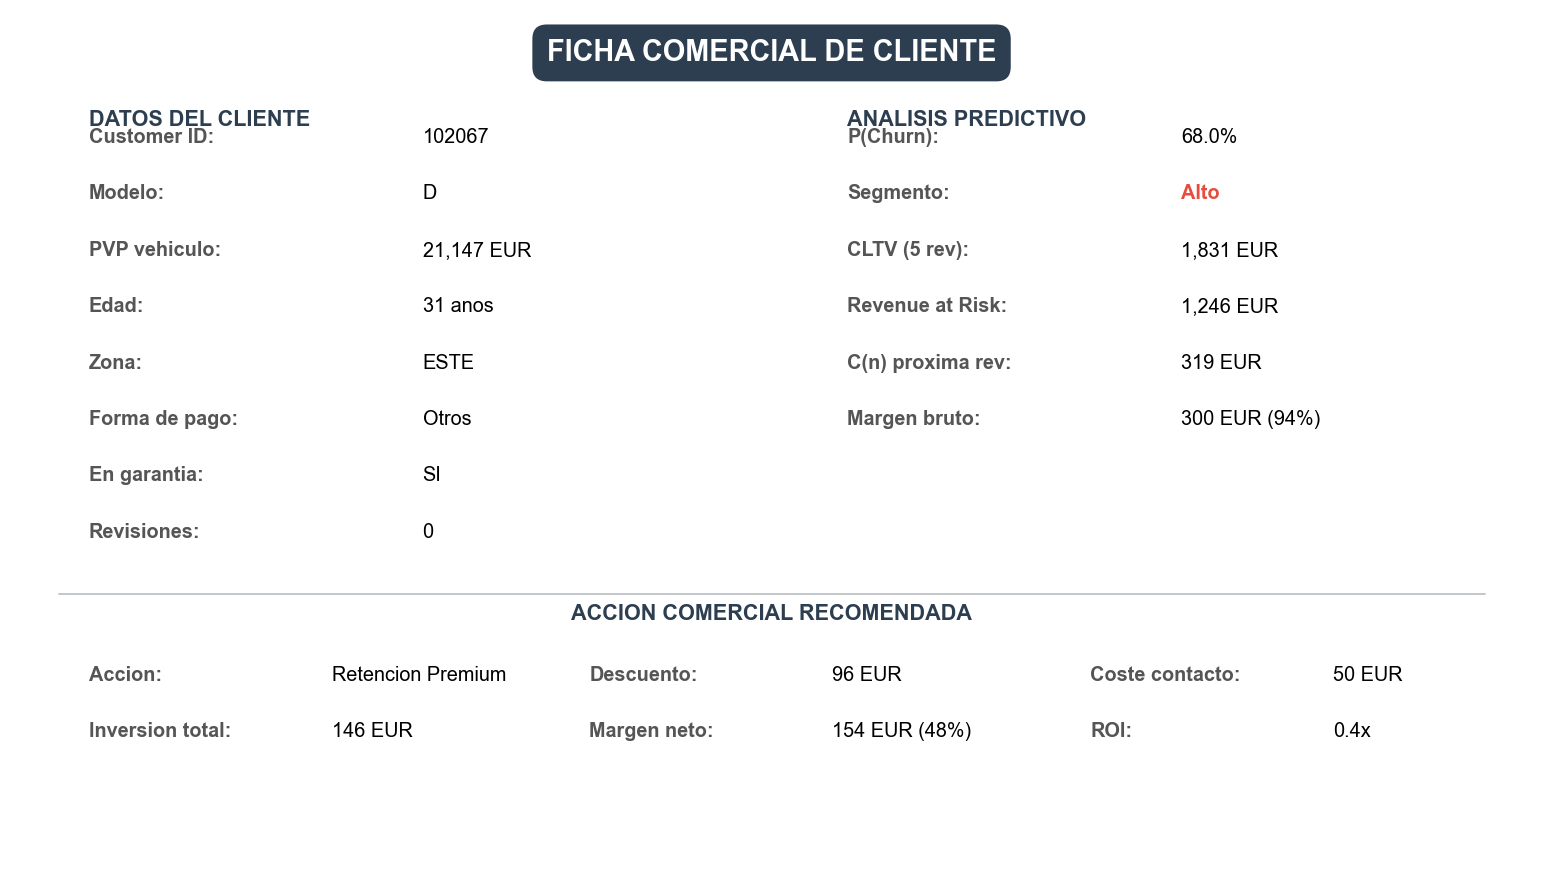

FICHA COMERCIAL DE CLIENTE
  Customer ID:        102067
  Modelo:             D
  PVP:                21,147 EUR
  P(Churn):           68.0%
  Segmento:           Alto
  CLTV (5 rev):       1,831 EUR
  Revenue at Risk:    1,246 EUR
  Accion:             Retencion Premium
  Inversion:          146 EUR
  Margen neto:        154 EUR (48%)
  ROI:                0.4x


In [30]:
# === 10.8 Ficha de Cliente ===

# Seleccionar el cliente con mayor Revenue at Risk
cliente_idx = df_biz["Revenue_at_Risk"].idxmax()
cl = df_biz.loc[cliente_idx]

# Datos originales del cliente
df_orig_ficha = pd.read_csv("nuevos_clientes.csv")
cl_orig = df_orig_ficha[df_orig_ficha["Customer_ID"] == cl["Customer_ID"]].iloc[0]

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

# Fondo
fig.patch.set_facecolor("white")

# Titulo
ax.text(0.5, 0.97, "FICHA COMERCIAL DE CLIENTE", fontsize=16, fontweight="bold",
        ha="center", va="top", transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#2c3e50", edgecolor="none"),
        color="white")

# Datos del cliente
color_riesgo = {"Alto": C_SI, "Medio": C_WARN, "Bajo": C_NO}
riesgo_cl = str(cl["Riesgo"])

y = 0.85
left_x = 0.05
right_x = 0.55
fs = 11

# Columna izquierda: Datos del cliente
campos_izq = [
    ("Customer ID:", f'{cl["Customer_ID"]}'),
    ("Modelo:", f'{cl["Modelo"]}'),
    ("PVP vehiculo:", f'{cl["PVP"]:,.0f} EUR'),
    ("Edad:", f'{cl_orig["Edad"]:.0f} anos'),
    ("Zona:", f'{cl_orig["ZONA"]}'),
    ("Forma de pago:", f'{cl_orig["FORMA_PAGO"]}'),
    ("En garantia:", f'{cl_orig["EN_GARANTIA"]}'),
    ("Revisiones:", f'{int(cl["Revisiones"])}'),
]

ax.text(left_x, y + 0.02, "DATOS DEL CLIENTE", fontsize=12, fontweight="bold",
        transform=ax.transAxes, color="#2c3e50")
for i, (label, valor) in enumerate(campos_izq):
    yi = y - i * 0.065
    ax.text(left_x, yi, label, fontsize=fs, fontweight="bold",
            transform=ax.transAxes, color="#555555")
    ax.text(left_x + 0.22, yi, valor, fontsize=fs,
            transform=ax.transAxes, color="black")

# Columna derecha: Analisis predictivo
campos_der = [
    ("P(Churn):", f'{cl["Prob_Churn"]:.1%}'),
    ("Segmento:", riesgo_cl),
    ("CLTV (5 rev):", f'{cl["CLTV"]:,.0f} EUR'),
    ("Revenue at Risk:", f'{cl["Revenue_at_Risk"]:,.0f} EUR'),
    ("C(n) proxima rev:", f'{cl["C_n"]:,.0f} EUR'),
    ("Margen bruto:", f'{cl["Margen_bruto"]:,.0f} EUR ({cl["Margen_bruto_pct"]:.0%})'),
]

ax.text(right_x, y + 0.02, "ANALISIS PREDICTIVO", fontsize=12, fontweight="bold",
        transform=ax.transAxes, color="#2c3e50")
for i, (label, valor) in enumerate(campos_der):
    yi = y - i * 0.065
    ax.text(right_x, yi, label, fontsize=fs, fontweight="bold",
            transform=ax.transAxes, color="#555555")
    color_val = color_riesgo.get(valor, "black")
    ax.text(right_x + 0.22, yi, valor, fontsize=fs,
            transform=ax.transAxes, color=color_val, fontweight="bold" if label == "Segmento:" else "normal")

# Seccion inferior: Accion comercial
y_acc = 0.28
ax.plot([0.03, 0.97], [y_acc + 0.05, y_acc + 0.05], color="#bdc3c7", lw=1, transform=ax.transAxes)
ax.text(0.5, y_acc + 0.02, "ACCION COMERCIAL RECOMENDADA", fontsize=12, fontweight="bold",
        ha="center", transform=ax.transAxes, color="#2c3e50")

campos_acc = [
    ("Accion:", f'{cl["Accion"]}'),
    ("Descuento:", f'{cl["Descuento"]:,.0f} EUR'),
    ("Coste contacto:", f'{cl["Coste_contacto"]:,.0f} EUR'),
    ("Inversion total:", f'{cl["Inversion_accion"]:,.0f} EUR'),
    ("Margen neto:", f'{cl["Margen_neto"]:,.0f} EUR ({cl["Margen_neto_pct"]:.0%})'),
    ("ROI:", f'{cl["ROI"]:.1f}x'),
]

for i, (label, valor) in enumerate(campos_acc):
    col = i % 3
    fila = i // 3
    xi = 0.05 + col * 0.33
    yi = y_acc - 0.05 - fila * 0.065
    ax.text(xi, yi, label, fontsize=fs, fontweight="bold",
            transform=ax.transAxes, color="#555555")
    ax.text(xi + 0.16, yi, valor, fontsize=fs,
            transform=ax.transAxes, color="black")

plt.tight_layout()
plt.show()

# Print version
print("FICHA COMERCIAL DE CLIENTE")
print("=" * 55)
print(f'  Customer ID:        {cl["Customer_ID"]}')
print(f'  Modelo:             {cl["Modelo"]}')
print(f'  PVP:                {cl["PVP"]:,.0f} EUR')
print(f'  P(Churn):           {cl["Prob_Churn"]:.1%}')
print(f'  Segmento:           {riesgo_cl}')
print(f'  CLTV (5 rev):       {cl["CLTV"]:,.0f} EUR')
print(f'  Revenue at Risk:    {cl["Revenue_at_Risk"]:,.0f} EUR')
print(f'  Accion:             {cl["Accion"]}')
print(f'  Inversion:          {cl["Inversion_accion"]:,.0f} EUR')
print(f'  Margen neto:        {cl["Margen_neto"]:,.0f} EUR ({cl["Margen_neto_pct"]:.0%})')
print(f'  ROI:                {cl["ROI"]:.1f}x')


---
## 11. Conclusiones y Recomendaciones

### Modelo predictivo

- **Modelo ganador:** Random Forest con 300 arboles, entrenado sobre poblacion activa (Rev >= 1)
  y sin variables de revisiones ni temporales (para evitar quasi-leakage).
- **AUC-ROC = 0.80 | AUC-PR = 0.38** sobre datos de test. En un dataset desbalanceado (8.8% churn),
  el modelo consigue identificar correctamente una proporcion significativa de clientes en riesgo.
- **Threshold optimizado** a partir de la curva F1, mejorando la deteccion frente al umbral por defecto (0.50).
- **Variables mas influyentes (SHAP):** estar fuera de garantia, no tener seguro de bateria,
  equipamiento bajo y potencia reducida son los principales factores de riesgo.

### Estrategia comercial

- Se definen **4 acciones comerciales** asignadas automaticamente por reglas de negocio
  (riesgo x valor CLTV), con descuentos del 5% al 20% sobre C(n).
- **Restriccion de margen:** toda accion respeta un margen neto minimo del 37%
  (30% concesionario + 7% comision marca). Si no se cumple, el descuento se ajusta automaticamente.
- **ROI positivo en todos los segmentos:** la inversion en retencion genera retornos
  consistentes porque las acciones son de bajo coste relativo frente a margenes altos de posventa.

### Impacto economico

- El modelo identifica **revenue at risk** significativo entre los clientes de alto riesgo,
  permitiendo al concesionario priorizar recursos donde mas impacto tienen.
- El **CLTV** (horizonte 5 revisiones) proporciona una vision de largo plazo que justifica
  la inversion en retencion incluso para clientes con margen unitario moderado.
- Los **20 clientes prioritarios** ofrecen un plan de accion inmediato y concreto.

### Limitaciones y proximos pasos

1. **Datos de revisiones:** Los clientes de staging tienen 0 revisiones previas (son nuevos),
   lo que limita la aplicabilidad de reglas basadas en fidelidad tecnica.
   En produccion, con datos historicos actualizados, se activarian reglas adicionales.
2. **Variables no disponibles:** No se dispone de datos de satisfaccion post-servicio,
   NPS, ni historico de comunicaciones comerciales. Incorporarlos mejoraria la prediccion.
3. **Monitorizacion:** El modelo debe recalibrarse periodicamente (cada 6-12 meses)
   para detectar data drift y mantener su capacidad predictiva.
4. **Validacion A/B:** Antes del despliegue completo, se recomienda un piloto A/B
   para medir el impacto real de las acciones comerciales sobre la retencion.


---
## 12. Exportar Artefactos (Streamlit)

Se exportan los artefactos necesarios para la aplicacion Streamlit:
- Modelo entrenado (.pkl)
- Columnas del modelo (.pkl)
- Threshold optimo (.pkl)
- SHAP values pre-computados (.pkl)
- Costes.csv


In [31]:
# === Exportar artefactos para Streamlit ===
import pickle
import os

export_dir = "streamlit_app/data"
os.makedirs(export_dir, exist_ok=True)

# 1. Modelo entrenado
with open(f"{export_dir}/modelo_churn.pkl", "wb") as f:
    pickle.dump(winner, f)
print(f"Modelo exportado: {winner_name}")

# 2. Columnas del modelo (orden exacto)
with open(f"{export_dir}/columnas_modelo.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)
print(f"Columnas exportadas: {len(X_train.columns)} features")

# 3. Threshold optimo
with open(f"{export_dir}/threshold.pkl", "wb") as f:
    pickle.dump(t_opt, f)
print(f"Threshold exportado: {t_opt:.4f}")

# 4. SHAP values + muestra (pre-computados para no recalcular en Streamlit)
shap_export = {
    "shap_values": shap_vals,
    "sample_data": shap_sample,
    "feature_names": list(shap_sample.columns),
}
with open(f"{export_dir}/shap_values.pkl", "wb") as f:
    pickle.dump(shap_export, f)
print(f"SHAP exportado: {shap_vals.shape[0]} clientes x {shap_vals.shape[1]} features")

# 5. Copiar Costes.csv
import shutil
shutil.copy("Costes.csv", f"{export_dir}/Costes.csv")
print("Costes.csv copiado")

print("")
print("Todos los artefactos exportados en:", export_dir)
print("Archivos:")
for fname in os.listdir(export_dir):
    size = os.path.getsize(export_dir + "/" + fname) / 1024
    print(f"  {fname:30s} {size:8.1f} KB")



Modelo exportado: Random Forest
Columnas exportadas: 64 features
Threshold exportado: 0.4984
SHAP exportado: 1000 clientes x 64 features
Costes.csv copiado

Todos los artefactos exportados en: streamlit_app/data
Archivos:
  columnas_modelo.pkl                 1.1 KB
  Costes.csv                          0.4 KB
  estrategia_comercial.csv         1464.2 KB
  modelo_churn.pkl                28234.7 KB
  model_metrics.pkl                   5.8 KB
  shap_values.pkl                  1010.3 KB
  staging_features.pkl             5080.7 KB
  threshold.pkl                       0.1 KB
